# Taylor Series: A Comprehensive Visualization Guide

## MLVerse-Math | Chapter: Taylor Series

**Python Version:** 3.12+ | **Last Updated:** 2026-06-30

---

## Table of Contents

1. Polynomial Approximation Animation
2. Taylor Series Build-Up Animation
3. Approximation Order Comparison
4. Error Visualization
5. Maclaurin Series Explorer
6. Radius of Convergence Visualization
7. Tangent vs Taylor Polynomial
8. Second-Order Surface Approximation
9. Optimization Landscape Approximation
10. Gradient and Hessian Visualization
11. Function Approximation Dashboard
12. Interactive Taylor Polynomial Explorer
13. AI Activation Function Approximation
14. Newton Method Animation
15. Interactive Taylor Dashboard

---

## Mathematical Foundation

The **Taylor series** of a function $f(x)$ about a point $a$:

$$f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!}(x-a)^n$$

**Maclaurin series** ($a = 0$):

$$f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(0)}{n!}x^n$$

### Key Applications in AI & ML

| Application | Role of Taylor Series |
|-------------|----------------------|
| **Newton's Method** | Second-order Taylor approximation for optimization |
| **Gradient Descent** | First-order (linear) approximation of loss landscape |
| **Neural Networks** | Activation function approximations (sigmoid, GELU) |
| **Optimization** | Hessian-based curvature analysis |
| **Scientific Computing** | Numerical differentiation and integration |

> **Note:** Run all cells sequentially. Interactive widgets require `ipywidgets`.
> ```bash
> pip install numpy sympy scipy matplotlib plotly ipywidgets pandas
> jupyter nbextension enable --py widgetsnbextension
> ```

In [1]:
# =============================================================================
# Cell 2: Library Imports and Global Configuration
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from numpy.polynomial import polynomial as P
import sympy as sp
sp.init_printing()
from scipy.special import factorial
from scipy.optimize import newton
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display, HTML, clear_output, Image


# Professional color palettes
COLORS = {
    'viridis': plt.cm.viridis,
    'plasma': plt.cm.plasma,
    'inferno': plt.cm.inferno,
    'cividis': plt.cm.cividis,
    'coolwarm': plt.cm.coolwarm,
}

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("All libraries imported successfully!")

All libraries imported successfully!


---

# Section 1: Polynomial Approximation Animation

## Mathematical Intuition

Polynomial approximation is the foundation of Taylor series. **Smooth functions can be locally approximated by polynomials**. As we include more terms (higher degree), the approximation becomes increasingly accurate near the expansion point.

### Taylor Polynomial Formula

$$P_n(x) = \sum_{k=0}^{n} \frac{f^{(k)}(a)}{k!}(x-a)^k$$

### Key Observations

1. **$e^x$** converges everywhere (infinite radius of convergence)
2. **$\sin(x)$** and **$\cos(x)$** also converge everywhere
3. Approximation quality degrades as $|x - a|$ increases
4. Higher-degree polynomials capture more oscillations

In [2]:
# =============================================================================
# Cell 3: Utility Functions for Taylor Series Computation
# =============================================================================

def compute_taylor_coefficients(f_sym, a, n_terms):
    """Compute Taylor series coefficients symbolically."""
    x = sp.Symbol('x')
    coeffs = []
    for k in range(n_terms):
        deriv = sp.diff(f_sym, x, k)
        coeff = float(deriv.subs(x, a)) / factorial(k)
        coeffs.append(coeff)
    return coeffs


def taylor_polynomial(x_vals, coeffs, a=0):
    """Evaluate Taylor polynomial at given x values."""
    x_vals = np.asarray(x_vals)
    y_vals = np.zeros_like(x_vals, dtype=float)
    for k, c in enumerate(coeffs):
        y_vals += c * (x_vals - a) ** k
    return y_vals


# Symbolic definitions for common functions
x_sym = sp.Symbol('x')
FUNCTIONS = {
    'exp': (sp.exp(x_sym), lambda x: np.exp(x), 'e^x'),
    'sin': (sp.sin(x_sym), lambda x: np.sin(x), 'sin(x)'),
    'cos': (sp.cos(x_sym), lambda x: np.cos(x), 'cos(x)'),
    'ln': (sp.log(1 + x_sym), lambda x: np.log(1 + x), 'ln(1+x)'),
    'sigmoid': (1 / (1 + sp.exp(-x_sym)), lambda x: 1/(1+np.exp(-x)), 'sigmoid(x)'),
    'tanh': (sp.tanh(x_sym), lambda x: np.tanh(x), 'tanh(x)'),
}

print("Utility functions defined successfully!")
print("Available functions:", list(FUNCTIONS.keys()))

Utility functions defined successfully!
Available functions: ['exp', 'sin', 'cos', 'ln', 'sigmoid', 'tanh']


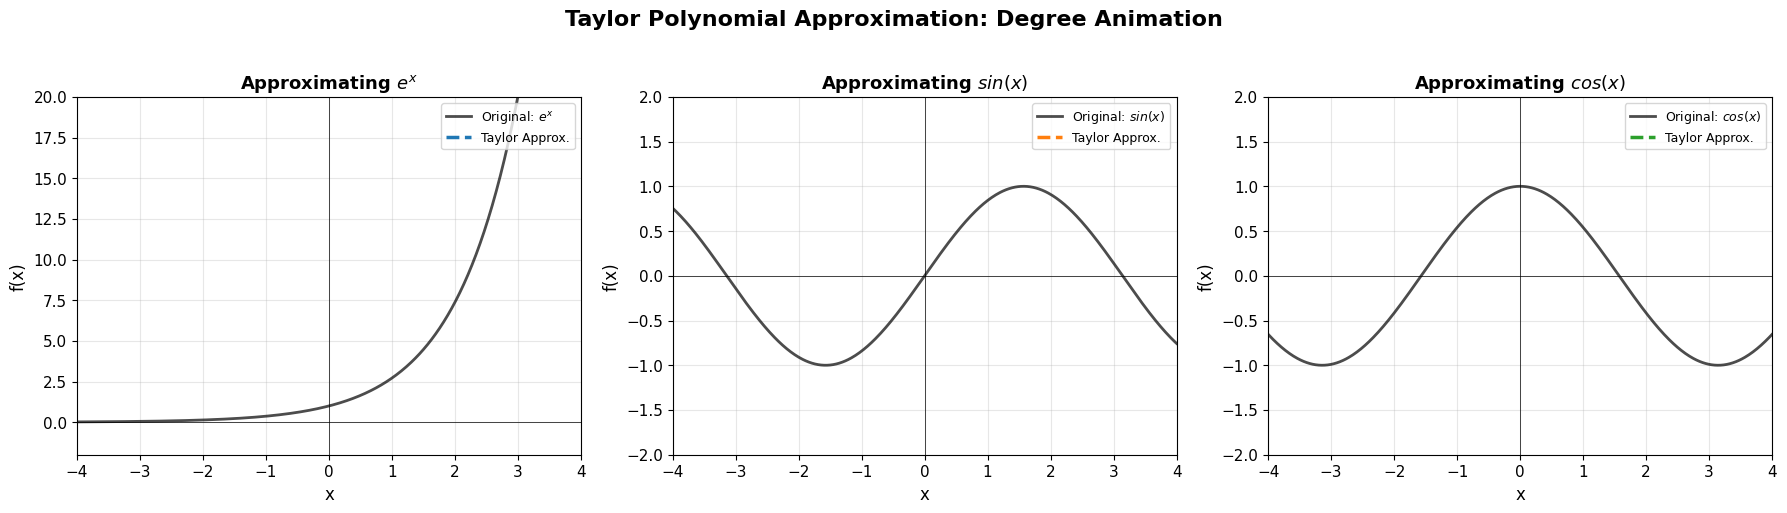

Animation created! The approximation improves as degree increases.


In [3]:
# =============================================================================
# Cell 4: Section 1 - Polynomial Approximation Animation
# =============================================================================

def create_polynomial_approximation_animation():
    """Animate polynomial approximation improving as degree increases."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Taylor Polynomial Approximation: Degree Animation', 
                 fontsize=16, fontweight='bold', y=1.02)

    x = np.linspace(-4, 4, 500)
    a = 0
    max_degree = 15

    funcs = [
        ('exp', np.exp(x), 'e^x', 'C0'),
        ('sin', np.sin(x), 'sin(x)', 'C1'),
        ('cos', np.cos(x), 'cos(x)', 'C2')
    ]

    lines_approx = []
    lines_original = []
    texts = []

    for idx, (name, y_true, label, color) in enumerate(funcs):
        ax = axes[idx]
        line_orig, = ax.plot(x, y_true, 'k-', linewidth=2, 
                            label=f'Original: ${label}$', alpha=0.7)
        lines_original.append(line_orig)
        line_approx, = ax.plot([], [], '--', linewidth=2.5, 
                              color=color, label=f'Taylor Approx.')
        lines_approx.append(line_approx)
        text = ax.text(0.05, 0.95, '', transform=ax.transAxes,
                      fontsize=12, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        texts.append(text)
        ax.set_xlim(-4, 4)
        if name == 'exp':
            ax.set_ylim(-2, 20)
        else:
            ax.set_ylim(-2, 2)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('f(x)', fontsize=12)
        ax.set_title(f'Approximating ${label}$', fontsize=13, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linewidth=0.5)
        ax.axvline(x=0, color='k', linewidth=0.5)

    def init():
        for line in lines_approx:
            line.set_data([], [])
        for text in texts:
            text.set_text('')
        return lines_approx + texts

    def animate(degree):
        for idx, (name, y_true, label, color) in enumerate(funcs):
            f_sym, f_np, _ = FUNCTIONS[name]
            coeffs = compute_taylor_coefficients(f_sym, a, degree + 1)
            y_approx = taylor_polynomial(x, coeffs, a)
            lines_approx[idx].set_data(x, y_approx)
            texts[idx].set_text(f'Degree: {degree}')
        return lines_approx + texts

    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                   frames=max_degree + 1, interval=800,
                                   blit=True, repeat=True)
    plt.tight_layout()
    plt.show()
    return anim

anim1 = create_polynomial_approximation_animation()
print("Animation created! The approximation improves as degree increases.")

In [4]:
# =============================================================================
# Cell 5: Interactive Degree Slider for Polynomial Approximation
# =============================================================================

@interact(
    func_name=widgets.Dropdown(
        options=[('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)', 'cos')],
        value='exp', description='Function:'
    ),
    degree=widgets.IntSlider(min=0, max=20, step=1, value=5,
        description='Degree:', continuous_update=False),
    a=widgets.FloatSlider(min=-3, max=3, step=0.1, value=0,
        description='Center a:', continuous_update=False),
    x_range=widgets.FloatRangeSlider(value=[-5, 5], min=-10, max=10, step=0.5,
        description='Domain:', continuous_update=False)
)
def interactive_polynomial_approximation(func_name, degree, a, x_range):
    """Interactive widget to explore Taylor polynomial approximation."""
    x = np.linspace(x_range[0], x_range[1], 1000)
    f_sym, f_np, label = FUNCTIONS[func_name]
    y_true = f_np(x)
    coeffs = compute_taylor_coefficients(f_sym, a, degree + 1)
    y_approx = taylor_polynomial(x, coeffs, a)
    error = np.abs(y_true - y_approx)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax1 = axes[0]
    ax1.plot(x, y_true, 'k-', linewidth=2, label=f'Original: ${label}$', alpha=0.8)
    ax1.plot(x, y_approx, 'r--', linewidth=2.5, 
            label=f'Taylor Polynomial (degree {degree})')
    ax1.axvline(x=a, color='blue', linestyle=':', alpha=0.7, label=f'Center $a={a}$')
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('f(x)', fontsize=12)
    ax1.set_title(f'Taylor Approximation of ${label}$ at $a={a}$', 
                 fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linewidth=0.5)

    ax2 = axes[1]
    ax2.semilogy(x, error + 1e-16, 'g-', linewidth=2)
    ax2.axvline(x=a, color='blue', linestyle=':', alpha=0.7)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('$|f(x) - P_n(x)|$', fontsize=12)
    ax2.set_title(f'Approximation Error (Degree {degree})', 
                 fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    print(f"\nTaylor Coefficients (centered at a={a}):")
    for i, c in enumerate(coeffs):
        if abs(c) > 1e-10:
            print(f"   c_{i} = {c:.6f}  ->  term: {c:.4f}*(x-{a})^{i}")
    print(f"\nMax absolute error in domain: {np.max(error):.6e}")

interactive(children=(Dropdown(description='Function:', options=(('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)',…

---

# Section 2: Taylor Series Build-Up Animation

## Mathematical Intuition

A Taylor series builds up term by term:

$$P_n(x) = \underbrace{f(a)}_{\text{Constant}} + \underbrace{f'(a)(x-a)}_{\text{Linear}} + \underbrace{\frac{f''(a)}{2!}(x-a)^2}_{\text{Quadratic}} + \underbrace{\frac{f'''(a)}{3!}(x-a)^3}_{\text{Cubic}} + \cdots$$

Each term captures a different aspect:
- **Constant term**: Function value at the center
- **Linear term**: Slope (first derivative)
- **Quadratic term**: Curvature (second derivative)
- **Cubic term**: Rate of change of curvature (third derivative)

### Real-World Motivation

In optimization, we truncate at different orders:
- **0th-order**: Function value (zero-order optimization)
- **1st-order**: Gradient (gradient descent)
- **2nd-order**: Hessian (Newton's method)
- **Higher-order**: Rare in practice due to computational cost

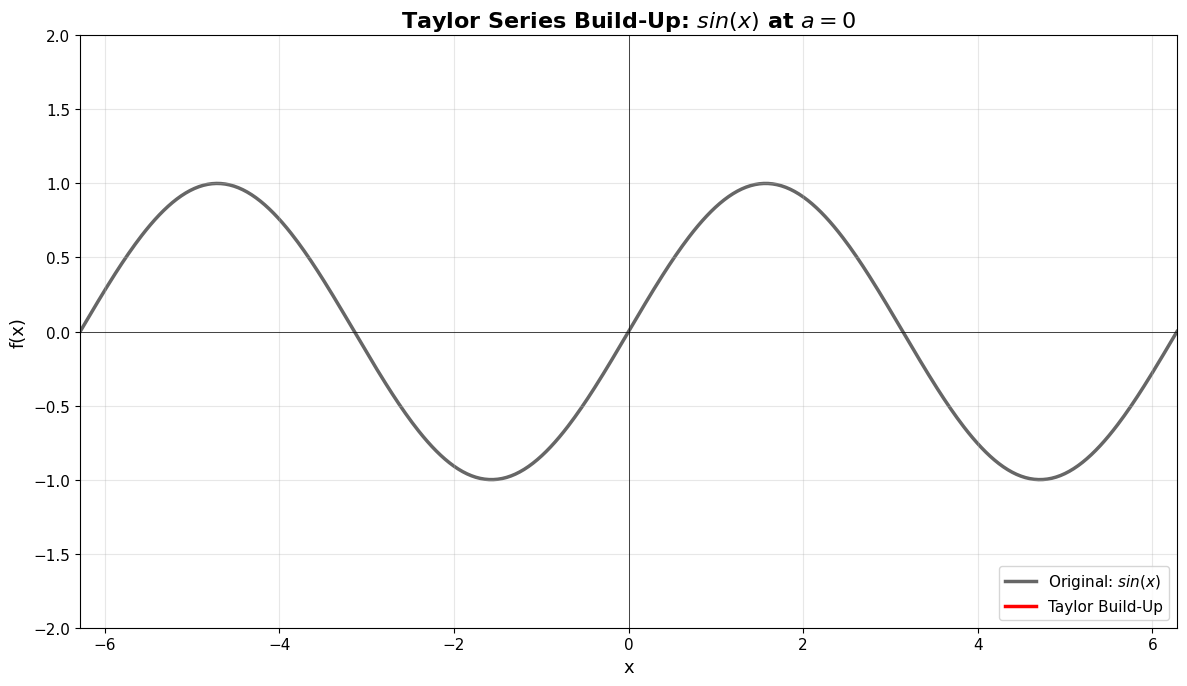

Build-up animation created! Watch how each term refines the approximation.


In [5]:
# =============================================================================
# Cell 7: Section 2 - Taylor Series Build-Up Animation
# =============================================================================

def create_buildup_animation(func_name='sin', a=0, max_degree=8):
    """Animate the build-up of Taylor series term by term."""
    x = np.linspace(-2*np.pi, 2*np.pi, 500)
    f_sym, f_np, label = FUNCTIONS[func_name]
    y_true = f_np(x)

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(x, y_true, 'k-', linewidth=2.5, label=f'Original: ${label}$', alpha=0.6, zorder=1)
    line_approx, = ax.plot([], [], 'r-', linewidth=2.5, label='Taylor Build-Up', zorder=3)
    term_text = ax.text(0.02, 0.98, '', transform=ax.transAxes,
                       fontsize=13, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='lightyellow', 
                                alpha=0.9, edgecolor='orange', linewidth=2), zorder=5)
    degree_text = ax.text(0.98, 0.98, '', transform=ax.transAxes,
                         fontsize=14, verticalalignment='top', horizontalalignment='right',
                         fontweight='bold',
                         bbox=dict(boxstyle='round', facecolor='lightblue', 
                                  alpha=0.9, edgecolor='blue', linewidth=2), zorder=5)
    fill_collection = ax.fill_between([], [], [], alpha=0.2, color='red', zorder=2)

    ax.set_xlim(-2*np.pi, 2*np.pi)
    ax.set_ylim(-2, 2)
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('f(x)', fontsize=13)
    ax.set_title(f'Taylor Series Build-Up: ${label}$ at $a={a}$', 
                fontsize=16, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    all_coeffs = compute_taylor_coefficients(f_sym, a, max_degree + 1)

    def init():
        line_approx.set_data([], [])
        term_text.set_text('')
        degree_text.set_text('')
        return line_approx, term_text, degree_text

    def animate(frame):
        degree = frame
        coeffs = all_coeffs[:degree + 1]
        y_approx = taylor_polynomial(x, coeffs, a)
        line_approx.set_data(x, y_approx)
        term_names = ['Constant', 'Linear', 'Quadratic', 'Cubic', 
                     'Quartic', 'Quintic', 'Sextic', 'Septic', 'Octic']
        if degree < len(term_names):
            term_name = term_names[degree]
        else:
            term_name = f"Order-{degree}"
        c = all_coeffs[degree]
        if abs(c) > 1e-10:
            term_formula = f"$\frac{{f^{{({degree})}}({a})}}{{{degree}!}}(x-{a})^{{{degree}}}$"
            if degree == 0:
                term_formula = f"$f({a}) = {c:.4f}$"
            term_text.set_text(f"Adding {term_name} term:\n{term_formula}\n\nValue: {c:.4f}")
        else:
            term_text.set_text(f"Adding {term_name} term:\nCoefficient ~ 0\n(Skipped)")
        degree_text.set_text(f'Degree: {degree}')
        nonlocal fill_collection
        fill_collection.remove()
        fill_collection = ax.fill_between(x, y_true, y_approx, 
                                        alpha=0.15, color='red', zorder=2)
        return line_approx, term_text, degree_text, fill_collection

    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                   frames=max_degree + 1, interval=1200,
                                   blit=False, repeat=True)
    plt.tight_layout()
    plt.show()
    return anim

anim2 = create_buildup_animation(func_name='sin', a=0, max_degree=8)
print("Build-up animation created! Watch how each term refines the approximation.")

In [6]:
# =============================================================================
# Cell 8: Interactive Taylor Build-Up Explorer
# =============================================================================

@interact(
    func_name=widgets.Dropdown(
        options=[('sin(x)', 'sin'), ('cos(x)', 'cos'), ('e^x', 'exp'), ('ln(1+x)', 'ln')],
        value='sin', description='Function:'
    ),
    degree=widgets.IntSlider(min=0, max=15, step=1, value=5,
        description='Degree:', continuous_update=False),
    a=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0,
        description='Center:', continuous_update=False),
    show_terms=widgets.Checkbox(value=True, description='Show individual terms')
)
def interactive_buildup_explorer(func_name, degree, a, show_terms):
    """Interactive explorer showing how each term contributes."""
    x = np.linspace(-4, 4, 500)
    f_sym, f_np, label = FUNCTIONS[func_name]
    y_true = f_np(x)
    all_coeffs = compute_taylor_coefficients(f_sym, a, degree + 1)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), 
                            gridspec_kw={'height_ratios': [2, 1]})

    ax1 = axes[0]
    ax1.plot(x, y_true, 'k-', linewidth=2.5, label=f'Original: ${label}$', alpha=0.6)
    y_cumulative = np.zeros_like(x)
    colors = plt.cm.viridis(np.linspace(0, 1, degree + 1))
    term_names = ['Constant', 'Linear', 'Quadratic', 'Cubic', 
                 'Quartic', 'Quintic', 'Sextic', 'Septic', 'Octic',
                 'Nonic', 'Decic', 'Undecic', 'Duodecic']

    for k in range(degree + 1):
        term = all_coeffs[k] * (x - a) ** k
        y_cumulative += term
        if show_terms and abs(all_coeffs[k]) > 1e-10:
            name = term_names[k] if k < len(term_names) else f"Order-{k}"
            ax1.plot(x, y_cumulative, '--', alpha=0.4, color=colors[k], 
                    linewidth=1.5, label=f'{name} (deg <= {k})')

    ax1.plot(x, y_cumulative, 'r-', linewidth=3, label=f'Final (degree {degree})')
    ax1.axvline(x=a, color='blue', linestyle=':', alpha=0.7, label=f'Center $a={a}$')
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('f(x)', fontsize=12)
    ax1.set_title(f'Taylor Build-Up: ${label}$ at $a={a}$, Degree {degree}', 
                 fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=8, ncol=2)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linewidth=0.5)

    ax2 = axes[1]
    error = np.abs(y_true - y_cumulative)
    ax2.semilogy(x, error + 1e-16, 'g-', linewidth=2)
    ax2.axvline(x=a, color='blue', linestyle=':', alpha=0.7)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('$|Error|$', fontsize=12)
    ax2.set_title('Approximation Error', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}")
    print(f"Taylor Coefficients for ${label}$ at $a = {a}$")
    print(f"{'='*60}")
    print(f"{'Degree':<10}{'Coefficient':<15}{'Term':<20}{'Contribution'}")
    print(f"{'-'*60}")
    for k, c in enumerate(all_coeffs):
        if abs(c) > 1e-10:
            term_str = f"{c:.4f}*(x-{a})^{k}"
            contrib = "Significant" if abs(c) > 0.01 else "Small"
            print(f"{k:<10}{c:<15.6f}{term_str:<20}{contrib}")
    print(f"{'='*60}")

interactive(children=(Dropdown(description='Function:', options=(('sin(x)', 'sin'), ('cos(x)', 'cos'), ('e^x',…

---

# Section 3: Approximation Order Comparison

## Mathematical Intuition

Different approximation orders serve different purposes:

| Order | Name | Formula | ML Application |
|-------|------|---------|--------------|
| 0 | Constant | $f(a)$ | Zero-order optimization |
| 1 | Linear | $f(a) + f'(a)(x-a)$ | Gradient descent |
| 2 | Quadratic | $+ \frac{f''(a)}{2}(x-a)^2$ | Newton's method |
| 3+ | Higher-order | Additional terms | Trust-region, Halley's method |

### Key Observations

1. Near the expansion point, even low-order approximations are accurate
2. As $|x - a|$ increases, higher orders are needed
3. There exists an optimal order for a given tolerance and domain
4. Computational cost grows with order

In [7]:
# =============================================================================
# Cell 10: Section 3 - Approximation Order Comparison
# =============================================================================

@interact(
    func_name=widgets.Dropdown(
        options=[('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)', 'cos'), ('ln(1+x)', 'ln')],
        value='exp', description='Function:'
    ),
    a=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0,
        description='Center:', continuous_update=False),
    x_max=widgets.FloatSlider(min=1, max=5, step=0.1, value=3,
        description='Domain +/-:', continuous_update=False),
    show_error=widgets.Checkbox(value=True, description='Show error subplot')
)
def order_comparison(func_name, a, x_max, show_error):
    """Compare Taylor approximations of different orders side by side."""
    x = np.linspace(a - x_max, a + x_max, 500)
    f_sym, f_np, label = FUNCTIONS[func_name]
    y_true = f_np(x)
    orders = [1, 2, 3, 5, 10, 20]
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

    if show_error:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        ax1, ax2 = axes
    else:
        fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(x, y_true, 'k-', linewidth=2.5, label=f'Original: ${label}$', alpha=0.7, zorder=10)
    ax1.axvline(x=a, color='blue', linestyle=':', alpha=0.5, linewidth=2, label=f'Center $a={a}$')

    for order, color in zip(orders, colors):
        try:
            coeffs = compute_taylor_coefficients(f_sym, a, order + 1)
            y_approx = taylor_polynomial(x, coeffs, a)
            ax1.plot(x, y_approx, '--', linewidth=2, color=color, 
                    alpha=0.8, label=f'Order {order}')
        except Exception as e:
            print(f"Warning: Could not compute order {order}: {e}")

    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('f(x)', fontsize=12)
    ax1.set_title(f'Order Comparison: ${label}$ at $a={a}$', 
                 fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=9, ncol=2)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linewidth=0.5)

    if show_error:
        for order, color in zip(orders, colors):
            try:
                coeffs = compute_taylor_coefficients(f_sym, a, order + 1)
                y_approx = taylor_polynomial(x, coeffs, a)
                error = np.abs(y_true - y_approx)
                ax2.semilogy(x, error + 1e-16, '-', linewidth=2, color=color, 
                           label=f'Order {order}')
            except:
                pass
        ax2.axvline(x=a, color='blue', linestyle=':', alpha=0.5, linewidth=2)
        ax2.set_xlabel('x', fontsize=12)
        ax2.set_ylabel('$|f(x) - P_n(x)|$', fontsize=12)
        ax2.set_title('Approximation Error by Order', fontsize=14, fontweight='bold')
        ax2.legend(loc='best', fontsize=9)
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*70}")
    print(f"Error Summary at x = {a + x_max/2:.2f} (mid-domain)")
    print(f"{'='*70}")
    print(f"{'Order':<10}{'Approximation':<20}{'True Value':<20}{'Error':<20}")
    print(f"{'-'*70}")
    test_point = a + x_max / 2
    y_true_pt = f_np(test_point)
    for order in orders:
        try:
            coeffs = compute_taylor_coefficients(f_sym, a, order + 1)
            y_approx_pt = taylor_polynomial([test_point], coeffs, a)[0]
            err = abs(y_true_pt - y_approx_pt)
            print(f"{order:<10}{y_approx_pt:<20.6f}{y_true_pt:<20.6f}{err:<20.6e}")
        except:
            print(f"{order:<10}{'N/A':<20}{y_true_pt:<20.6f}{'N/A':<20}")
    print(f"{'='*70}")

interactive(children=(Dropdown(description='Function:', options=(('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)',…

---

# Section 4: Error Visualization

## Mathematical Intuition

The **Taylor remainder** (error) quantifies how much the polynomial approximation deviates from the true function:

$$R_n(x) = f(x) - P_n(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!}(x-a)^{n+1}$$

for some $\xi$ between $a$ and $x$ (Lagrange form of the remainder).

### Key Observations

1. Error is minimized at the expansion point ($x = a$)
2. Error generally increases with $|x - a|$
3. Higher degrees reduce error but may cause oscillations (Runge phenomenon)
4. Error heatmaps reveal "safe zones" for approximations

In [8]:
# =============================================================================
# Cell 12: Section 4 - Error Visualization with Heatmap
# =============================================================================

@interact(
    func_name=widgets.Dropdown(
        options=[('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)', 'cos'), ('ln(1+x)', 'ln')],
        value='sin', description='Function:'
    ),
    max_degree=widgets.IntSlider(min=1, max=30, step=1, value=15,
        description='Max Degree:', continuous_update=False),
    a=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0,
        description='Center:', continuous_update=False)
)
def error_heatmap_visualization(func_name, max_degree, a):
    """Create an error heatmap showing approximation error."""
    f_sym, f_np, label = FUNCTIONS[func_name]
    x_vals = np.linspace(a - 3, a + 3, 200)
    degrees = np.arange(0, max_degree + 1)
    error_matrix = np.zeros((len(degrees), len(x_vals)))

    for i, deg in enumerate(degrees):
        try:
            coeffs = compute_taylor_coefficients(f_sym, a, deg + 1)
            y_approx = taylor_polynomial(x_vals, coeffs, a)
            y_true = f_np(x_vals)
            error_matrix[i, :] = np.abs(y_true - y_approx)
        except:
            error_matrix[i, :] = np.nan

    error_matrix = np.clip(error_matrix, 1e-16, 10)

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'Error Heatmap: Degree vs Position',
            'Error at Specific Degrees',
            'Error vs Degree at Fixed Points',
            'Convergence Analysis'
        ),
        specs=[[{"type": "heatmap"}, {"type": "scatter"}],
               [{"type": "scatter"}, {"type": "scatter"}]],
        vertical_spacing=0.12, horizontal_spacing=0.1
    )

    fig.add_trace(
        go.Heatmap(
            z=np.log10(error_matrix), x=x_vals, y=degrees,
            colorscale='Inferno',
            colorbar=dict(title='log10|Error|', x=0.45),
            hovertemplate='x: %{x:.2f}<br>Degree: %{y}<br>log10|Error|: %{z:.2f}<extra></extra>'
        ), row=1, col=1
    )
    fig.add_vline(x=a, line_dash="dash", line_color="blue", row=1, col=1)

    selected_degrees = [1, 3, 5, 10, 15, 20]
    colors = px.colors.qualitative.Set1
    for idx, deg in enumerate(selected_degrees):
        if deg <= max_degree:
            fig.add_trace(
                go.Scatter(x=x_vals, y=np.log10(error_matrix[deg, :] + 1e-16),
                    mode='lines', name=f'Degree {deg}',
                    line=dict(color=colors[idx % len(colors)], width=2)), row=1, col=2
            )

    test_points = [a - 1.5, a - 0.5, a + 0.5, a + 1.5]
    for idx, tp in enumerate(test_points):
        x_idx = np.argmin(np.abs(x_vals - tp))
        errors_at_point = error_matrix[:, x_idx]
        fig.add_trace(
            go.Scatter(x=degrees, y=np.log10(errors_at_point + 1e-16),
                mode='lines+markers', name=f'x = {tp:.1f}',
                line=dict(color=colors[idx % len(colors)], width=2),
                marker=dict(size=6)), row=2, col=1
        )

    neighborhood = np.abs(x_vals - a) <= 1.0
    max_errors = []
    for i, deg in enumerate(degrees):
        if np.any(neighborhood):
            max_errors.append(np.max(error_matrix[i, neighborhood]))
        else:
            max_errors.append(np.nan)

    fig.add_trace(
        go.Scatter(x=degrees, y=np.log10(np.array(max_errors) + 1e-16),
            mode='lines+markers', name='Max Error (|x-a|<=1)',
            line=dict(color='red', width=3),
            marker=dict(size=8, symbol='diamond')), row=2, col=2
    )

    fig.update_layout(
        title=dict(text=f'Error Visualization for ${label}$ at $a={a}$', font=dict(size=18)),
        height=800, showlegend=True, template='plotly_white'
    )
    fig.update_xaxes(title_text='x', row=1, col=1)
    fig.update_yaxes(title_text='Polynomial Degree', row=1, col=1)
    fig.update_xaxes(title_text='x', row=1, col=2)
    fig.update_yaxes(title_text='log10|Error|', row=1, col=2)
    fig.update_xaxes(title_text='Polynomial Degree', row=2, col=1)
    fig.update_yaxes(title_text='log10|Error|', row=2, col=1)
    fig.update_xaxes(title_text='Polynomial Degree', row=2, col=2)
    fig.update_yaxes(title_text='log10|Error|', row=2, col=2)
    fig.show()

    print(f"\nError Analysis Summary for ${label}$ at $a={a}$:")
    print(f"   - Minimum error occurs at x = {a} (the expansion point)")
    print(f"   - Error generally increases with |x - a|")
    print(f"   - Higher degrees reduce error in the convergence region")
    print(f"   - Watch for divergence outside the radius of convergence")

interactive(children=(Dropdown(description='Function:', index=1, options=(('e^x', 'exp'), ('sin(x)', 'sin'), (…

---

# Section 5: Maclaurin Series Explorer

## Mathematical Intuition

A **Maclaurin series** is a Taylor series centered at $a = 0$:

$$f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(0)}{n!}x^n$$

### Common Maclaurin Series

| Function | Series | Radius of Convergence |
|----------|--------|----------------------|
| $e^x$ | $\sum_{n=0}^{\infty} \frac{x^n}{n!}$ | $\infty$ |
| $\sin(x)$ | $\sum_{n=0}^{\infty} \frac{(-1)^n x^{2n+1}}{(2n+1)!}$ | $\infty$ |
| $\cos(x)$ | $\sum_{n=0}^{\infty} \frac{(-1)^n x^{2n}}{(2n)!}$ | $\infty$ |
| $\ln(1+x)$ | $\sum_{n=1}^{\infty} \frac{(-1)^{n+1} x^n}{n}$ | $1$ |

### Key Observations

1. Even functions ($\cos(x)$) have only even powers
2. Odd functions ($\sin(x)$) have only odd powers
3. $\ln(1+x)$ has radius of convergence $R = 1$
4. $e^x$ converges for all $x$ but may overflow numerically

In [9]:
# =============================================================================
# Cell 14: Section 5 - Interactive Maclaurin Series Explorer
# =============================================================================

@interact(
    func_name=widgets.Dropdown(
        options=[('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)', 'cos'), ('ln(1+x)', 'ln')],
        value='exp', description='Function:'
    ),
    degree=widgets.IntSlider(min=1, max=50, step=1, value=10,
        description='Degree:', continuous_update=False),
    zoom=widgets.FloatSlider(min=0.5, max=5, step=0.1, value=2,
        description='Zoom:', continuous_update=False),
    show_series=widgets.Checkbox(value=True, description='Show series formula')
)
def maclaurin_explorer(func_name, degree, zoom, show_series):
    """Interactive Maclaurin series explorer with zoom and domain controls."""
    x = np.linspace(-zoom, zoom, 500)
    f_sym, f_np, label = FUNCTIONS[func_name]
    y_true = f_np(x)
    coeffs = compute_taylor_coefficients(f_sym, 0, degree + 1)
    y_approx = taylor_polynomial(x, coeffs, 0)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    ax1 = axes[0, 0]
    ax1.plot(x, y_true, 'k-', linewidth=2.5, label=f'Original: ${label}$', alpha=0.7)
    ax1.plot(x, y_approx, 'r--', linewidth=2.5, label=f'Maclaurin (degree {degree})')
    ax1.axvline(x=0, color='blue', linestyle=':', alpha=0.7, label='Center $a=0$')
    if func_name == 'ln':
        ax1.axvline(x=1, color='orange', linestyle='--', alpha=0.7, label='R = 1 (diverges)')
        ax1.axvline(x=-1, color='orange', linestyle='--', alpha=0.7)
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('f(x)', fontsize=12)
    ax1.set_title(f'Maclaurin Approximation: ${label}$', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linewidth=0.5)

    ax2 = axes[0, 1]
    error = np.abs(y_true - y_approx)
    valid_mask = np.isfinite(error) & (error < 1e10)
    ax2.semilogy(x[valid_mask], error[valid_mask] + 1e-16, 'g-', linewidth=2)
    ax2.axvline(x=0, color='blue', linestyle=':', alpha=0.7)
    if func_name == 'ln':
        ax2.axvline(x=1, color='orange', linestyle='--', alpha=0.7)
        ax2.axvline(x=-1, color='orange', linestyle='--', alpha=0.7)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('$|f(x) - P_n(x)|$', fontsize=12)
    ax2.set_title('Approximation Error', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    deg_range = np.arange(len(coeffs))
    coeff_mags = np.abs(coeffs)
    valid_coeffs = coeff_mags > 1e-15
    ax3.bar(deg_range[valid_coeffs], coeff_mags[valid_coeffs], 
           color='steelblue', alpha=0.7, edgecolor='navy')
    ax3.set_xlabel('Degree', fontsize=12)
    ax3.set_ylabel('$|c_n|$', fontsize=12)
    ax3.set_title('Coefficient Magnitudes', fontsize=14, fontweight='bold')
    ax3.set_yscale('log')
    ax3.grid(True, alpha=0.3, axis='y')

    ax4 = axes[1, 1]
    test_points = [-zoom*0.7, -zoom*0.3, zoom*0.3, zoom*0.7]
    colors_tp = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    for tp, color in zip(test_points, colors_tp):
        errors_vs_deg = []
        for d in range(degree + 1):
            c = compute_taylor_coefficients(f_sym, 0, d + 1)
            approx = taylor_polynomial([tp], c, 0)[0]
            true_val = f_np(tp)
            err = abs(true_val - approx)
            errors_vs_deg.append(err if np.isfinite(err) else np.nan)
        ax4.semilogy(range(degree + 1), np.array(errors_vs_deg) + 1e-16, 
                    'o-', color=color, linewidth=2, markersize=4, label=f'x = {tp:.2f}')
    ax4.set_xlabel('Polynomial Degree', fontsize=12)
    ax4.set_ylabel('$|Error|$', fontsize=12)
    ax4.set_title('Convergence by Degree', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if show_series:
        print(f"\n{'='*70}")
        print(f"Maclaurin Series for ${label}$ (degree {degree})")
        print(f"{'='*70}")
        series_str = f"$P_{{{degree}}}(x) = "
        terms = []
        for i, c in enumerate(coeffs):
            if abs(c) > 1e-10:
                if i == 0:
                    terms.append(f"{c:.4f}")
                elif i == 1:
                    terms.append(f"{c:.4f}x")
                else:
                    terms.append(f"{c:.4f}x^{{{i}}}")
        series_str += " + ".join(terms) + "$"
        print(series_str)
        print(f"{'='*70}")
        if func_name == 'ln':
            print(f"\n⚠️  Radius of Convergence: R = 1")
            print(f"   The series converges for $-1 < x \leq 1$")
            print(f"   Diverges for $|x| > 1$")
        elif func_name in ['exp', 'sin', 'cos']:
            print(f"\n✅ Radius of Convergence: R = ∞")
            print(f"   The series converges for all $x \in \mathbb{{R}}$")
        print(f"{'='*70}")

interactive(children=(Dropdown(description='Function:', options=(('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)',…

---

# Section 6: Radius of Convergence Visualization

## Mathematical Intuition

The **radius of convergence** $R$ is the distance from the expansion point within which the Taylor series converges:

$$R = \frac{1}{\limsup_{n \to \infty} |c_n|^{1/n}}$$

For a power series $\sum c_n (x-a)^n$:
- **Converges absolutely** for $|x - a| < R$
- **Diverges** for $|x - a| > R$
- **Behavior at boundary** ($|x - a| = R$) must be checked case by case

### Key Observations

1. $e^x$, $\sin(x)$, $\cos(x)$: $R = \infty$ (entire functions)
2. $\ln(1+x)$: $R = 1$ (singularity at $x = -1$)
3. $\frac{1}{1-x}$: $R = 1$ (pole at $x = 1$)
4. At the boundary, convergence depends on the specific series

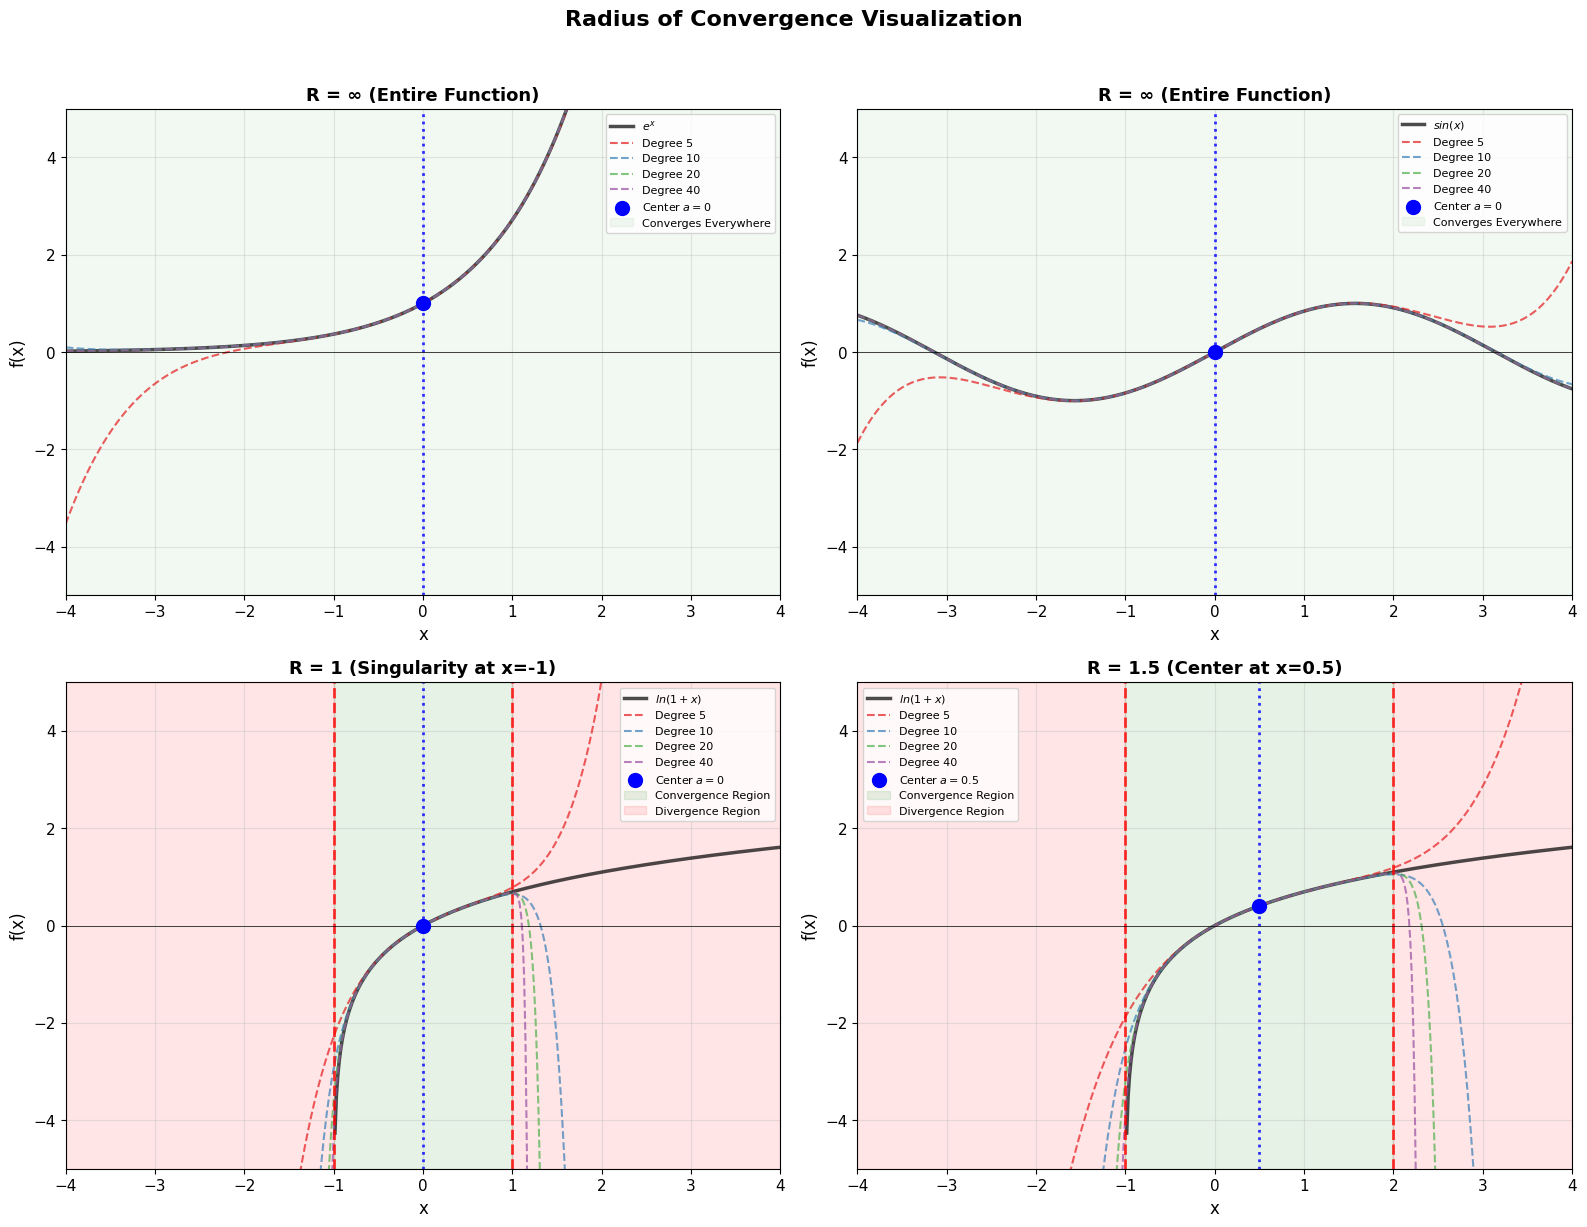

Observe how approximations behave inside vs. outside the radius of convergence!


In [10]:
# =============================================================================
# Cell 16: Section 6 - Radius of Convergence Visualization
# =============================================================================

def visualize_radius_of_convergence():
    """Visualize radius of convergence for functions with different radii."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    configs = [
        ('exp', 0, np.inf, 'e^x', 'R = ∞ (Entire Function)'),
        ('sin', 0, np.inf, 'sin(x)', 'R = ∞ (Entire Function)'),
        ('ln', 0, 1, 'ln(1+x)', 'R = 1 (Singularity at x=-1)'),
        ('ln', 0.5, 1.5, 'ln(1+x)', 'R = 1.5 (Center at x=0.5)'),
    ]

    x_full = np.linspace(-4, 4, 500)

    for idx, (func_name, a, R, label, title) in enumerate(configs):
        ax = axes[idx // 2, idx % 2]
        f_sym, f_np, _ = FUNCTIONS[func_name]

        y_true = f_np(x_full)
        if func_name == 'ln':
            y_true = np.where(x_full > -1, y_true, np.nan)

        ax.plot(x_full, y_true, 'k-', linewidth=2.5, label=f'${label}$', alpha=0.7)

        degrees = [5, 10, 20, 40]
        colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

        for deg, color in zip(degrees, colors):
            try:
                coeffs = compute_taylor_coefficients(f_sym, a, deg + 1)
                y_approx = taylor_polynomial(x_full, coeffs, a)
                y_approx = np.clip(y_approx, -50, 50)
                ax.plot(x_full, y_approx, '--', linewidth=1.5, color=color, 
                       alpha=0.7, label=f'Degree {deg}')
            except Exception as e:
                pass

        ax.axvline(x=a, color='blue', linestyle=':', alpha=0.8, linewidth=2)
        ax.scatter([a], [f_np(a) if func_name != 'ln' or a > -1 else np.nan], 
                  color='blue', s=100, zorder=10, label=f'Center $a={a}$')

        if R != np.inf:
            ax.axvline(x=a + R, color='red', linestyle='--', alpha=0.8, linewidth=2)
            ax.axvline(x=a - R, color='red', linestyle='--', alpha=0.8, linewidth=2)
            ax.axvspan(a - R, a + R, alpha=0.1, color='green', label='Convergence Region')
            ax.axvspan(x_full[0], a - R, alpha=0.1, color='red')
            ax.axvspan(a + R, x_full[-1], alpha=0.1, color='red', label='Divergence Region')
        else:
            ax.axvspan(x_full[0], x_full[-1], alpha=0.05, color='green', label='Converges Everywhere')

        ax.set_xlim(-4, 4)
        ax.set_ylim(-5, 5)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('f(x)', fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linewidth=0.5)

    plt.suptitle('Radius of Convergence Visualization', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

visualize_radius_of_convergence()
print("Observe how approximations behave inside vs. outside the radius of convergence!")

In [11]:
# =============================================================================
# Cell 17: Interactive Radius of Convergence Explorer
# =============================================================================

@interact(
    func_name=widgets.Dropdown(
        options=[('ln(1+x)', 'ln'), ('1/(1-x) [simulated]', 'ln')],
        value='ln', description='Function:'
    ),
    a=widgets.FloatSlider(min=-1.5, max=1.5, step=0.1, value=0,
        description='Center:', continuous_update=False),
    degree=widgets.IntSlider(min=5, max=50, step=1, value=15,
        description='Degree:', continuous_update=False),
    show_radius=widgets.Checkbox(value=True, description='Show convergence radius')
)
def interactive_radius_explorer(func_name, a, degree, show_radius):
    """Interactive radius of convergence explorer."""
    x = np.linspace(-3, 3, 500)
    f_sym, f_np, label = FUNCTIONS['ln']

    y_true = np.where(x > -1, f_np(x), np.nan)

    coeffs = compute_taylor_coefficients(f_sym, a, degree + 1)
    y_approx = taylor_polynomial(x, coeffs, a)
    y_approx = np.clip(y_approx, -20, 20)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax1 = axes[0]
    ax1.plot(x, y_true, 'k-', linewidth=2.5, label=f'Original: ${label}$', alpha=0.7)
    ax1.plot(x, y_approx, 'r--', linewidth=2.5, label=f'Taylor (degree {degree})')
    ax1.axvline(x=a, color='blue', linestyle=':', alpha=0.8, linewidth=2, label=f'Center $a={a}$')

    R = abs(a + 1)

    if show_radius:
        ax1.axvline(x=a + R, color='red', linestyle='--', alpha=0.8, linewidth=2)
        ax1.axvline(x=a - R, color='red', linestyle='--', alpha=0.8, linewidth=2)
        ax1.axvspan(a - R, a + R, alpha=0.1, color='green', label=f'Converges (R={R:.2f})')
        if a - R > -3:
            ax1.axvspan(-3, a - R, alpha=0.1, color='red', label='Diverges')
        if a + R < 3:
            ax1.axvspan(a + R, 3, alpha=0.1, color='red')

    ax1.set_xlim(-3, 3)
    ax1.set_ylim(-5, 5)
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('f(x)', fontsize=12)
    ax1.set_title(f'Radius of Convergence for ${label}$', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linewidth=0.5)

    ax2 = axes[1]
    error = np.abs(y_true - y_approx)
    valid = np.isfinite(error) & (error < 100)
    ax2.semilogy(x[valid], error[valid] + 1e-16, 'g-', linewidth=2)
    ax2.axvline(x=a, color='blue', linestyle=':', alpha=0.8, linewidth=2)

    if show_radius:
        ax2.axvline(x=a + R, color='red', linestyle='--', alpha=0.8, linewidth=2)
        ax2.axvline(x=a - R, color='red', linestyle='--', alpha=0.8, linewidth=2)
        ax2.axvspan(a - R, a + R, alpha=0.1, color='green')

    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('$|f(x) - P_n(x)|$', fontsize=12)
    ax2.set_title('Approximation Error', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}")
    print(f"Radius of Convergence Analysis")
    print(f"{'='*60}")
    print(f"Function: ${label}$")
    print(f"Expansion point: a = {a}")
    print(f"Singularity: x = -1")
    print(f"Radius: R = |a - (-1)| = {R:.4f}")
    print(f"Convergence interval: ({a-R:.4f}, {a+R:.4f})")
    print(f"{'='*60}")
    print(f"\n💡 Key Insight: Moving the center away from the singularity")
    print(f"   increases the radius of convergence!")

interactive(children=(Dropdown(description='Function:', options=(('ln(1+x)', 'ln'), ('1/(1-x) [simulated]', 'l…

---

# Section 7: Tangent vs Taylor Polynomial

## Mathematical Intuition

Compare different orders of Taylor approximation to understand local accuracy:

- **Tangent Line** (1st order): $P_1(x) = f(a) + f'(a)(x-a)$
- **Quadratic** (2nd order): $P_2(x) = P_1(x) + \frac{f''(a)}{2}(x-a)^2$
- **Cubic** (3rd order): $P_3(x) = P_2(x) + \frac{f'''(a)}{6}(x-a)^3$
- **5th order**: $P_5(x) = P_3(x) + \cdots$

### Key Observations

1. The tangent line matches value and slope at $x = a$
2. Quadratic adds curvature matching
3. Higher orders match more derivatives
4. Local accuracy improves dramatically with each order

In [12]:
# =============================================================================
# Cell 19: Section 7 - Tangent vs Taylor Polynomial Comparison
# =============================================================================

@interact(
    func_name=widgets.Dropdown(
        options=[('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)', 'cos')],
        value='sin', description='Function:'
    ),
    a=widgets.FloatSlider(min=-2, max=2, step=0.1, value=1.0,
        description='Center:', continuous_update=False),
    zoom=widgets.FloatSlider(min=0.1, max=3, step=0.1, value=1.5,
        description='Zoom:', continuous_update=False)
)
def tangent_vs_taylor(func_name, a, zoom):
    """Compare tangent line vs higher-order Taylor polynomials."""
    x = np.linspace(a - zoom, a + zoom, 500)
    f_sym, f_np, label = FUNCTIONS[func_name]
    y_true = f_np(x)

    orders = [1, 2, 3, 5]
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    labels = ['Tangent (Order 1)', 'Quadratic (Order 2)', 'Cubic (Order 3)', 'Order 5']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax1 = axes[0]
    ax1.plot(x, y_true, 'k-', linewidth=3, label=f'Original: ${label}$', alpha=0.8, zorder=10)
    ax1.axvline(x=a, color='gray', linestyle=':', alpha=0.5)
    ax1.axhline(y=f_np(a), color='gray', linestyle=':', alpha=0.5)

    for order, color, lbl in zip(orders, colors, labels):
        coeffs = compute_taylor_coefficients(f_sym, a, order + 1)
        y_approx = taylor_polynomial(x, coeffs, a)
        ax1.plot(x, y_approx, '--', linewidth=2.5, color=color, 
                alpha=0.8, label=lbl, zorder=5)

    ax1.scatter([a], [f_np(a)], color='black', s=150, zorder=15, 
               edgecolors='white', linewidths=2, label=f'Expansion Point $a={a}$')
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('f(x)', fontsize=12)
    ax1.set_title(f'Local Accuracy Comparison at $a={a}$', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linewidth=0.5)

    ax2 = axes[1]
    for order, color, lbl in zip(orders, colors, labels):
        coeffs = compute_taylor_coefficients(f_sym, a, order + 1)
        y_approx = taylor_polynomial(x, coeffs, a)
        error = np.abs(y_true - y_approx)
        ax2.semilogy(x, error + 1e-16, '-', linewidth=2.5, color=color, 
                    alpha=0.8, label=lbl)

    ax2.axvline(x=a, color='gray', linestyle=':', alpha=0.5)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('$|f(x) - P_n(x)|$', fontsize=12)
    ax2.set_title('Local Approximation Error', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}")
    print(f"Local Accuracy Analysis at $a = {a}$")
    print(f"{'='*60}")
    print(f"{'Order':<15}{'Error at a+0.1':<20}{'Error at a+0.5':<20}")
    print(f"{'-'*60}")
    for order in orders:
        coeffs = compute_taylor_coefficients(f_sym, a, order + 1)
        err1 = abs(f_np(a + 0.1) - taylor_polynomial([a + 0.1], coeffs, a)[0])
        err2 = abs(f_np(a + 0.5) - taylor_polynomial([a + 0.5], coeffs, a)[0])
        print(f"{order:<15}{err1:<20.6e}{err2:<20.6e}")
    print(f"{'='*60}")

interactive(children=(Dropdown(description='Function:', index=1, options=(('e^x', 'exp'), ('sin(x)', 'sin'), (…

---

# Section 8: Second-Order Surface Approximation

## Mathematical Intuition

For a function $f(x, y)$, the second-order Taylor approximation near $(a, b)$ is:

$$f(x, y) \approx f(a,b) + \nabla f(a,b)^T \begin{bmatrix} x-a \ y-b \end{bmatrix} + \frac{1}{2} \begin{bmatrix} x-a & y-b \end{bmatrix} H(a,b) \begin{bmatrix} x-a \ y-b \end{bmatrix}$$

where $H$ is the **Hessian matrix**:

$$H = \begin{bmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{bmatrix}$$

### Key Observations

1. The tangent plane is the first-order approximation
2. The Hessian captures local curvature
3. Eigenvalues of $H$ determine concavity/convexity
4. Critical points are classified by $H$ (min, max, saddle)

In [13]:
# =============================================================================
# Cell 21: Section 8 - Second-Order Surface Approximation (3D)
# =============================================================================

@interact(
    func_choice=widgets.Dropdown(
        options=[('Rosenbrock', 'rosenbrock'), ('Saddle', 'saddle'), ('Bowl', 'bowl')],
        value='rosenbrock', description='Surface:'
    ),
    a=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5,
        description='Center x:', continuous_update=False),
    b=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5,
        description='Center y:', continuous_update=False),
    zoom=widgets.FloatSlider(min=0.5, max=3, step=0.1, value=1.5,
        description='Zoom:', continuous_update=False)
)
def surface_approximation(func_choice, a, b, zoom):
    """Visualize original 3D surface vs second-order Taylor approximation."""

    if func_choice == 'rosenbrock':
        def f(x, y):
            return (1 - x)**2 + 100*(y - x**2)**2
        def grad_f(x, y):
            dx = -2*(1 - x) - 400*x*(y - x**2)
            dy = 200*(y - x**2)
            return np.array([dx, dy])
        def hess_f(x, y):
            dxx = 2 - 400*y + 1200*x**2
            dxy = -400*x
            dyy = 200
            return np.array([[dxx, dxy], [dxy, dyy]])
        title = 'Rosenbrock Function'
    elif func_choice == 'saddle':
        def f(x, y):
            return x**2 - y**2
        def grad_f(x, y):
            return np.array([2*x, -2*y])
        def hess_f(x, y):
            return np.array([[2, 0], [0, -2]])
        title = 'Saddle Point'
    else:  # bowl
        def f(x, y):
            return x**2 + y**2
        def grad_f(x, y):
            return np.array([2*x, 2*y])
        def hess_f(x, y):
            return np.array([[2, 0], [0, 2]])
        title = 'Bowl (Convex)'

    # Create grid
    x = np.linspace(a - zoom, a + zoom, 50)
    y = np.linspace(b - zoom, b + zoom, 50)
    X, Y = np.meshgrid(x, y)

    # Original surface
    Z_true = f(X, Y)

    # Second-order Taylor approximation
    f0 = f(a, b)
    g = grad_f(a, b)
    H = hess_f(a, b)

    Z_approx = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            dx = X[i, j] - a
            dy = Y[i, j] - b
            d = np.array([dx, dy])
            Z_approx[i, j] = f0 + g.dot(d) + 0.5 * d.dot(H.dot(d))

    # Plotly 3D visualization
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'surface'}, {'type': 'surface'}]],
        subplot_titles=(f'Original: {title}', 'Second-Order Taylor Approximation')
    )

    fig.add_trace(
        go.Surface(x=X, y=Y, z=Z_true, colorscale='Viridis',
                  colorbar=dict(title='f(x,y)', x=0.45),
                  showscale=True),
        row=1, col=1
    )

    fig.add_trace(
        go.Surface(x=X, y=Y, z=Z_approx, colorscale='Plasma',
                  colorbar=dict(title='Approx', x=1.0),
                  showscale=True),
        row=1, col=2
    )

    # Mark expansion point
    fig.add_trace(
        go.Scatter3d(x=[a], y=[b], z=[f0],
                    mode='markers', marker=dict(size=8, color='red'),
                    name='Expansion Point'),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter3d(x=[a], y=[b], z=[f0],
                    mode='markers', marker=dict(size=8, color='red'),
                    name='Expansion Point'),
        row=1, col=2
    )

    fig.update_layout(
        title=dict(text=f'3D Surface Approximation at ({a}, {b})', font=dict(size=18)),
        height=600, width=1200,
        scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='f(x,y)'),
        scene2=dict(xaxis_title='x', yaxis_title='y', zaxis_title='Approximation')
    )

    fig.show()

    # Print analysis
    print(f"\n{'='*60}")
    print(f"Second-Order Taylor Analysis at ({a}, {b})")
    print(f"{'='*60}")
    print(f"f({a}, {b}) = {f0:.4f}")
    print(f"Gradient: {g}")
    print(f"Hessian:\n{H}")
    eigenvalues = np.linalg.eigvals(H)
    print(f"Hessian Eigenvalues: {eigenvalues}")
    if np.all(eigenvalues > 0):
        print("Classification: Local Minimum (Positive Definite)")
    elif np.all(eigenvalues < 0):
        print("Classification: Local Maximum (Negative Definite)")
    elif np.any(eigenvalues > 0) and np.any(eigenvalues < 0):
        print("Classification: Saddle Point (Indefinite)")
    else:
        print("Classification: Degenerate (Semi-definite)")
    print(f"{'='*60}")

interactive(children=(Dropdown(description='Surface:', options=(('Rosenbrock', 'rosenbrock'), ('Saddle', 'sadd…

---

# Section 9: Optimization Landscape Approximation

## Mathematical Intuition

Optimization algorithms use local Taylor approximations to navigate loss landscapes:

- **Gradient Descent**: Uses first-order approximation to find descent direction
- **Newton's Method**: Uses second-order approximation for faster convergence
- **Trust Region**: Limits step size based on approximation quality

The loss surface $L(\theta)$ is approximated near current parameters $\theta_0$:

$$L(\theta) \approx L(\theta_0) + \nabla L(\theta_0)^T (\theta - \theta_0) + \frac{1}{2}(\theta - \theta_0)^T H(\theta_0) (\theta - \theta_0)$$

### Key Observations

1. First-order methods are cheap but slow near minima
2. Second-order methods are expensive but converge faster
3. The Hessian determines the "shape" of the local bowl
4. Ill-conditioned Hessians cause slow convergence

In [14]:
# =============================================================================
# Cell 23: Section 9 - Optimization Landscape Approximation
# =============================================================================

@interact(
    func_choice=widgets.Dropdown(
        options=[('Rosenbrock', 'rosenbrock'), ('Beale', 'beale'), ('Matyas', 'matyas')],
        value='rosenbrock', description='Loss Surface:'
    ),
    theta1=widgets.FloatSlider(min=-2, max=2, step=0.1, value=1.5,
        description='theta1:', continuous_update=False),
    theta2=widgets.FloatSlider(min=-2, max=2, step=0.1, value=1.5,
        description='theta2:', continuous_update=False),
    show_contours=widgets.Checkbox(value=True, description='Show contour lines')
)
def optimization_landscape(func_choice, theta1, theta2, show_contours):
    """Display original loss surface and Taylor approximation."""

    if func_choice == 'rosenbrock':
        def loss(t1, t2):
            return (1 - t1)**2 + 100*(t2 - t1**2)**2
        def grad_loss(t1, t2):
            return np.array([-2*(1-t1) - 400*t1*(t2-t1**2), 200*(t2-t1**2)])
        def hess_loss(t1, t2):
            return np.array([[2 - 400*t2 + 1200*t1**2, -400*t1],
                           [-400*t1, 200]])
        title = 'Rosenbrock Loss Surface'
    elif func_choice == 'beale':
        def loss(t1, t2):
            return (1.5 - t1 + t1*t2)**2 + (2.25 - t1 + t1*t2**2)**2 + (2.625 - t1 + t1*t2**3)**2
        def grad_loss(t1, t2):
            dx = 2*(1.5-t1+t1*t2)*(-1+t2) + 2*(2.25-t1+t1*t2**2)*(-1+t2**2) + 2*(2.625-t1+t1*t2**3)*(-1+t2**3)
            dy = 2*(1.5-t1+t1*t2)*(t1) + 2*(2.25-t1+t1*t2**2)*(2*t1*t2) + 2*(2.625-t1+t1*t2**3)*(3*t1*t2**2)
            return np.array([dx, dy])
        def hess_loss(t1, t2):
            return np.eye(2)  # Approximation
        title = 'Beale Loss Surface'
    else:  # matyas
        def loss(t1, t2):
            return 0.26*(t1**2 + t2**2) - 0.48*t1*t2
        def grad_loss(t1, t2):
            return np.array([0.52*t1 - 0.48*t2, 0.52*t2 - 0.48*t1])
        def hess_loss(t1, t2):
            return np.array([[0.52, -0.48], [-0.48, 0.52]])
        title = 'Matyas Loss Surface'

    # Grid
    t1_range = np.linspace(-2, 2, 100)
    t2_range = np.linspace(-2, 2, 100)
    T1, T2 = np.meshgrid(t1_range, t2_range)

    # Original loss
    L_true = loss(T1, T2)

    # Taylor approximation
    L0 = loss(theta1, theta2)
    g = grad_loss(theta1, theta2)
    H = hess_loss(theta1, theta2)

    L_approx = np.zeros_like(T1)
    for i in range(T1.shape[0]):
        for j in range(T1.shape[1]):
            d = np.array([T1[i,j] - theta1, T2[i,j] - theta2])
            L_approx[i,j] = L0 + g.dot(d) + 0.5 * d.dot(H.dot(d))

    # Clip for visualization
    L_true = np.clip(L_true, 0, 500)
    L_approx = np.clip(L_approx, -100, 500)

    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'surface'}, {'type': 'surface'}]],
        subplot_titles=(f'Original: {title}', 'Second-Order Taylor Approximation')
    )

    fig.add_trace(
        go.Surface(x=T1, y=T2, z=L_true, colorscale='Viridis',
                  colorbar=dict(title='Loss', x=0.45), showscale=True),
        row=1, col=1
    )

    fig.add_trace(
        go.Surface(x=T1, y=T2, z=L_approx, colorscale='Plasma',
                  colorbar=dict(title='Approx', x=1.0), showscale=True),
        row=1, col=2
    )

    # Mark current point
    fig.add_trace(
        go.Scatter3d(x=[theta1], y=[theta2], z=[L0],
                    mode='markers', marker=dict(size=10, color='red', symbol='diamond'),
                    name='Current Point'), row=1, col=1
    )
    fig.add_trace(
        go.Scatter3d(x=[theta1], y=[theta2], z=[L0],
                    mode='markers', marker=dict(size=10, color='red', symbol='diamond'),
                    name='Current Point'), row=1, col=2
    )

    fig.update_layout(
        title=dict(text=f'Optimization Landscape at ({theta1}, {theta2})', font=dict(size=18)),
        height=600, width=1200,
        scene=dict(xaxis_title='theta1', yaxis_title='theta2', zaxis_title='Loss'),
        scene2=dict(xaxis_title='theta1', yaxis_title='theta2', zaxis_title='Approximation')
    )

    fig.show()

    # Contour plot comparison
    fig2, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax1 = axes[0]
    cs1 = ax1.contourf(T1, T2, L_true, levels=20, cmap='viridis')
    ax1.contour(T1, T2, L_true, levels=20, colors='white', alpha=0.3, linewidths=0.5)
    ax1.scatter([theta1], [theta2], color='red', s=100, marker='x', linewidths=3, label='Current Point')
    ax1.set_xlabel('theta1', fontsize=12)
    ax1.set_ylabel('theta2', fontsize=12)
    ax1.set_title('Original Loss Contours', fontsize=14, fontweight='bold')
    ax1.legend()
    plt.colorbar(cs1, ax=ax1, label='Loss')

    ax2 = axes[1]
    cs2 = ax2.contourf(T1, T2, L_approx, levels=20, cmap='plasma')
    ax2.contour(T1, T2, L_approx, levels=20, colors='white', alpha=0.3, linewidths=0.5)
    ax2.scatter([theta1], [theta2], color='red', s=100, marker='x', linewidths=3, label='Current Point')
    ax2.set_xlabel('theta1', fontsize=12)
    ax2.set_ylabel('theta2', fontsize=12)
    ax2.set_title('Taylor Approximation Contours', fontsize=14, fontweight='bold')
    ax2.legend()
    plt.colorbar(cs2, ax=ax2, label='Approximation')

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}")
    print(f"Optimization Analysis at ({theta1}, {theta2})")
    print(f"{'='*60}")
    print(f"Loss: L = {L0:.4f}")
    print(f"Gradient: {g}")
    print(f"Gradient Norm: {np.linalg.norm(g):.4f}")
    print(f"Hessian:\n{H}")
    print(f"\nWhy optimization uses local approximations:")
    print(f"  1. Computing full loss is expensive for large models")
    print(f"  2. Gradient points in steepest descent direction")
    print(f"  3. Hessian curvature guides step size")
    print(f"  4. Taylor approximations make optimization tractable")
    print(f"{'='*60}")

interactive(children=(Dropdown(description='Loss Surface:', options=(('Rosenbrock', 'rosenbrock'), ('Beale', '…

---

# Section 10: Gradient and Hessian Visualization

## Mathematical Intuition

For a multivariate function $f(x, y)$:

**Gradient** (vector of first derivatives):
$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$$

**Hessian** (matrix of second derivatives):
$$H = \begin{bmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{bmatrix}$$

The Taylor approximation combines these:
$$f(x) \approx f(a) + \nabla f(a)^T (x-a) + \frac{1}{2}(x-a)^T H(a) (x-a)$$

### Key Observations

1. Gradient arrows point in the direction of steepest ascent
2. Hessian eigenvectors indicate principal curvature directions
3. Positive eigenvalues -> convex (valley), negative -> concave (ridge)
4. The Taylor approximation is exact for quadratic functions

In [ ]:
# =============================================================================
# Cell 25: Section 10 - Gradient and Hessian Visualization
# =============================================================================

@interact(
    func_choice=widgets.Dropdown(
        options=[('Bowl', 'bowl'), ('Saddle', 'saddle'), ('Rosenbrock', 'rosenbrock')],
        value='bowl', description='Function:'
    ),
    a=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5,
        description='x:', continuous_update=False),
    b=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5,
        description='y:', continuous_update=False)
)
def gradient_hessian_viz(func_choice, a, b):
    """Visualize gradient, Hessian, and Taylor approximation."""

    if func_choice == 'bowl':
        def f(x, y):
            return x**2 + y**2
        def grad_f(x, y):
            return np.array([2*x, 2*y])
        def hess_f(x, y):
            return np.array([[2, 0], [0, 2]])
        title = 'Bowl: f(x,y) = x^2 + y^2'
    elif func_choice == 'saddle':
        def f(x, y):
            return x**2 - y**2
        def grad_f(x, y):
            return np.array([2*x, -2*y])
        def hess_f(x, y):
            return np.array([[2, 0], [0, -2]])
        title = 'Saddle: f(x,y) = x^2 - y^2'
    else:  # rosenbrock
        def f(x, y):
            return (1 - x)**2 + 100*(y - x**2)**2
        def grad_f(x, y):
            return np.array([-2*(1-x) - 400*x*(y-x**2), 200*(y-x**2)])
        def hess_f(x, y):
            return np.array([[2 - 400*y + 1200*x**2, -400*x],
                           [-400*x, 200]])
        title = 'Rosenbrock'

    # Grid
    x = np.linspace(-2, 2, 30)
    y = np.linspace(-2, 2, 30)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)
    Z = np.clip(Z, 0, 100)

    # Compute gradient field
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            g = grad_f(X[i,j], Y[i,j])
            U[i,j] = g[0]
            V[i,j] = g[1]

    # Normalize for visualization
    grad_norm = np.sqrt(U**2 + V**2)
    U_norm = U / (grad_norm + 1e-10)
    V_norm = V / (grad_norm + 1e-10)

    # Current point analysis
    f0 = f(a, b)
    g0 = grad_f(a, b)
    H0 = hess_f(a, b)
    eigenvalues, eigenvectors = np.linalg.eig(H0)

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # Plot 1: Surface with gradient arrows
    ax1 = axes[0, 0]
    cs = ax1.contourf(X, Y, Z, levels=20, cmap='viridis')
    ax1.contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)
    ax1.quiver(X, Y, U_norm, V_norm, grad_norm, cmap='plasma', alpha=0.7, scale=30)
    ax1.scatter([a], [b], color='red', s=200, marker='*', edgecolors='white', linewidths=2, zorder=10)
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('y', fontsize=12)
    ax1.set_title(f'{title}: Gradient Field', fontsize=14, fontweight='bold')
    plt.colorbar(cs, ax=ax1, label='f(x,y)')

    # Plot 2: Hessian curvature ellipses
    ax2 = axes[0, 1]
    ax2.contourf(X, Y, Z, levels=20, cmap='coolwarm')
    # Draw curvature ellipse at current point
    theta = np.linspace(0, 2*np.pi, 100)
    for ev, ev_vec in zip(eigenvalues, eigenvectors.T):
        if ev != 0:
            r = 1.0 / np.sqrt(abs(ev) + 1e-10)
            ellipse_x = a + r * ev_vec[0] * np.cos(theta)
            ellipse_y = b + r * ev_vec[1] * np.cos(theta)
            ax2.plot(ellipse_x, ellipse_y, 'w-', linewidth=2, alpha=0.8)
    ax2.scatter([a], [b], color='red', s=200, marker='*', edgecolors='white', linewidths=2, zorder=10)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('y', fontsize=12)
    ax2.set_title('Hessian Curvature Ellipses', fontsize=14, fontweight='bold')
    ax2.set_xlim(-2, 2)
    ax2.set_ylim(-2, 2)

    # Plot 3: Taylor approximation surface
    ax3 = axes[1, 0]
    Z_approx = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            d = np.array([X[i,j] - a, Y[i,j] - b])
            Z_approx[i,j] = f0 + g0.dot(d) + 0.5 * d.dot(H0.dot(d))
    Z_approx = np.clip(Z_approx, -50, 100)
    cs3 = ax3.contourf(X, Y, Z_approx, levels=20, cmap='plasma')
    ax3.contour(X, Y, Z_approx, levels=20, colors='white', alpha=0.3, linewidths=0.5)
    ax3.scatter([a], [b], color='red', s=200, marker='*', edgecolors='white', linewidths=2, zorder=10)
    ax3.set_xlabel('x', fontsize=12)
    ax3.set_ylabel('y', fontsize=12)
    ax3.set_title('Second-Order Taylor Approximation', fontsize=14, fontweight='bold')
    plt.colorbar(cs3, ax=ax3, label='Approximation')

    # Plot 4: Error surface
    ax4 = axes[1, 1]
    Z_error = np.abs(Z - Z_approx)
    Z_error = np.clip(Z_error, 0, 50)
    cs4 = ax4.contourf(X, Y, Z_error, levels=20, cmap='inferno')
    ax4.contour(X, Y, Z_error, levels=20, colors='white', alpha=0.3, linewidths=0.5)
    ax4.scatter([a], [b], color='red', s=200, marker='*', edgecolors='white', linewidths=2, zorder=10)
    ax4.set_xlabel('x', fontsize=12)
    ax4.set_ylabel('y', fontsize=12)
    ax4.set_title('Approximation Error |f - Taylor|', fontsize=14, fontweight='bold')
    plt.colorbar(cs4, ax=ax4, label='Error')

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}")
    print(f"Gradient and Hessian Analysis at ({a}, {b})")
    print(f"{'='*60}")
    print(f"f({a}, {b}) = {f0:.4f}")
    print(f"\nGradient: \nabla f = {g0}")
    print(f"Gradient Norm: {np.linalg.norm(g0):.4f}")
    print(f"\nHessian:")
    print(f"{H0}")
    print(f"\nEigenvalues: {eigenvalues}")
    print(f"Eigenvectors:\n{eigenvectors}")
    print(f"\nLocal Geometry:")
    if np.all(eigenvalues > 0):
        print("  - Positive definite: Local minimum (bowl shape)")
    elif np.all(eigenvalues < 0):
        print("  - Negative definite: Local maximum (inverted bowl)")
    elif np.any(eigenvalues > 0) and np.any(eigenvalues < 0):
        print("  - Indefinite: Saddle point")
    print(f"{'='*60}")

interactive(children=(Dropdown(description='Function:', options=(('Bowl', 'bowl'), ('Saddle', 'saddle'), ('Ros…

---

# Section 11: Function Approximation Dashboard

## Mathematical Intuition

A comprehensive dashboard combining all key elements of Taylor approximation:
- Original function plot
- Taylor polynomial overlay
- Error visualization
- Interactive parameter controls

This dashboard demonstrates how all components work together in a single interface.

In [16]:
# =============================================================================
# Cell 27: Section 11 - Function Approximation Dashboard
# =============================================================================

# Create the dashboard layout
func_dropdown = widgets.Dropdown(
    options=[('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)', 'cos'), ('ln(1+x)', 'ln')],
    value='exp', description='Function:'
)
degree_slider = widgets.IntSlider(min=1, max=30, step=1, value=5, description='Degree:')
center_slider = widgets.FloatSlider(min=-3, max=3, step=0.1, value=0, description='Center:')
domain_slider = widgets.FloatRangeSlider(value=[-5, 5], min=-10, max=10, step=0.5, description='Domain:')
show_error_cb = widgets.Checkbox(value=True, description='Show Error')
show_coeffs_cb = widgets.Checkbox(value=True, description='Show Coefficients')

ui = widgets.VBox([
    widgets.HBox([func_dropdown, degree_slider]),
    widgets.HBox([center_slider, domain_slider]),
    widgets.HBox([show_error_cb, show_coeffs_cb])
])

out = widgets.Output()

def update_dashboard(func_name, degree, center, domain, show_error, show_coeffs):
    with out:
        out.clear_output(wait=True)
        x = np.linspace(domain[0], domain[1], 1000)
        f_sym, f_np, label = FUNCTIONS[func_name]
        y_true = f_np(x)

        coeffs = compute_taylor_coefficients(f_sym, center, degree + 1)
        y_approx = taylor_polynomial(x, coeffs, center)
        error = np.abs(y_true - y_approx)

        n_plots = 2 if show_error else 1
        if show_coeffs:
            n_plots += 1

        fig = plt.figure(figsize=(16, 5 * n_plots))

        # Main plot
        ax1 = plt.subplot(n_plots, 1, 1)
        ax1.plot(x, y_true, 'k-', linewidth=2.5, label=f'Original: ${label}$', alpha=0.8)
        ax1.plot(x, y_approx, 'r--', linewidth=2.5, label=f'Taylor (degree {degree})')
        ax1.axvline(x=center, color='blue', linestyle=':', alpha=0.7, label=f'Center $a={center}$')
        ax1.set_xlabel('x', fontsize=12)
        ax1.set_ylabel('f(x)', fontsize=12)
        ax1.set_title(f'Taylor Approximation Dashboard: ${label}$', fontsize=16, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)
        ax1.axhline(y=0, color='k', linewidth=0.5)

        plot_idx = 2

        if show_error:
            ax2 = plt.subplot(n_plots, 1, plot_idx)
            valid = np.isfinite(error) & (error < 1e10)
            ax2.semilogy(x[valid], error[valid] + 1e-16, 'g-', linewidth=2)
            ax2.axvline(x=center, color='blue', linestyle=':', alpha=0.7)
            ax2.set_xlabel('x', fontsize=12)
            ax2.set_ylabel('$|f(x) - P_n(x)|$', fontsize=12)
            ax2.set_title('Approximation Error', fontsize=14, fontweight='bold')
            ax2.grid(True, alpha=0.3)
            plot_idx += 1

        if show_coeffs:
            ax3 = plt.subplot(n_plots, 1, plot_idx)
            deg_range = np.arange(len(coeffs))
            coeff_mags = np.abs(coeffs)
            valid = coeff_mags > 1e-15
            ax3.bar(deg_range[valid], coeff_mags[valid], color='steelblue', alpha=0.7, edgecolor='navy')
            ax3.set_xlabel('Degree', fontsize=12)
            ax3.set_ylabel('$|c_n|$', fontsize=12)
            ax3.set_title('Taylor Coefficient Magnitudes', fontsize=14, fontweight='bold')
            ax3.set_yscale('log')
            ax3.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()

        print(f"\n{'='*60}")
        print(f"Dashboard Summary: ${label}$ at $a={center}$, degree {degree}")
        print(f"{'='*60}")
        print(f"Max error in domain: {np.max(error):.6e}")
        print(f"Mean error in domain: {np.mean(error):.6e}")
        print(f"{'='*60}")

# Link widgets to update function
interactive_plot = widgets.interactive_output(
    update_dashboard,
    {'func_name': func_dropdown, 'degree': degree_slider, 'center': center_slider,
     'domain': domain_slider, 'show_error': show_error_cb, 'show_coeffs': show_coeffs_cb}
)

display(ui, out, interactive_plot)
print("Dashboard loaded! Use controls above to explore Taylor approximations.")

Output()

Output()

Dashboard loaded! Use controls above to explore Taylor approximations.


---

# Section 12: Interactive Taylor Polynomial Explorer

## Mathematical Intuition

A fully interactive explorer allowing users to choose:
- **Function**: Any available function
- **Approximation point**: Any real number
- **Polynomial degree**: From 1 to 50
- **Domain**: Adjustable zoom range

This provides complete freedom to explore Taylor series behavior across all parameters.

In [17]:
# =============================================================================
# Cell 29: Section 12 - Interactive Taylor Polynomial Explorer
# =============================================================================

@interact(
    func_name=widgets.Dropdown(
        options=[('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)', 'cos'), 
                 ('ln(1+x)', 'ln'), ('sigmoid(x)', 'sigmoid'), ('tanh(x)', 'tanh')],
        value='exp', description='Function:'
    ),
    a=widgets.FloatSlider(min=-5, max=5, step=0.1, value=0,
        description='Center a:', continuous_update=False),
    degree=widgets.IntSlider(min=1, max=50, step=1, value=10,
        description='Degree:', continuous_update=False),
    x_min=widgets.FloatSlider(min=-10, max=-0.1, step=0.1, value=-5,
        description='x min:', continuous_update=False),
    x_max=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=5,
        description='x max:', continuous_update=False),
    show_derivatives=widgets.Checkbox(value=False, description='Show derivative info')
)
def taylor_explorer(func_name, a, degree, x_min, x_max, show_derivatives):
    """Fully interactive Taylor polynomial explorer."""
    x = np.linspace(x_min, x_max, 1000)
    f_sym, f_np, label = FUNCTIONS[func_name]
    y_true = f_np(x)

    coeffs = compute_taylor_coefficients(f_sym, a, degree + 1)
    y_approx = taylor_polynomial(x, coeffs, a)
    error = np.abs(y_true - y_approx)

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            f'Function: ${label}$',
            'Taylor Polynomial Approximation',
            'Approximation Error',
            'Coefficient Magnitudes'
        ),
        vertical_spacing=0.12, horizontal_spacing=0.1
    )

    # Plot 1: Original function
    fig.add_trace(
        go.Scatter(x=x, y=y_true, mode='lines', name=f'Original: ${label}$',
                  line=dict(color='black', width=2)), row=1, col=1
    )
    fig.add_vline(x=a, line_dash="dash", line_color="blue", row=1, col=1)

    # Plot 2: Approximation
    fig.add_trace(
        go.Scatter(x=x, y=y_approx, mode='lines', name=f'Taylor (degree {degree})',
                  line=dict(color='red', width=2, dash='dash')), row=1, col=2
    )
    fig.add_trace(
        go.Scatter(x=x, y=y_true, mode='lines', name=f'Original',
                  line=dict(color='black', width=1, opacity=0.5)), row=1, col=2
    )
    fig.add_vline(x=a, line_dash="dash", line_color="blue", row=1, col=2)

    # Plot 3: Error
    valid = np.isfinite(error) & (error < 1e10)
    fig.add_trace(
        go.Scatter(x=x[valid], y=np.log10(error[valid] + 1e-16), mode='lines',
                  name='log10|Error|', line=dict(color='green', width=2)), row=2, col=1
    )
    fig.add_vline(x=a, line_dash="dash", line_color="blue", row=2, col=1)

    # Plot 4: Coefficients
    deg_range = np.arange(len(coeffs))
    coeff_mags = np.abs(coeffs)
    valid_c = coeff_mags > 1e-15
    fig.add_trace(
        go.Bar(x=deg_range[valid_c], y=coeff_mags[valid_c], name='|c_n|',
              marker_color='steelblue'), row=2, col=2
    )

    fig.update_layout(
        title=dict(text=f'Taylor Explorer: ${label}$ at $a={a}$, degree {degree}',
                  font=dict(size=18)),
        height=800, showlegend=True, template='plotly_white'
    )
    fig.update_yaxes(type="log", row=2, col=2)

    fig.show()

    print(f"\n{'='*60}")
    print(f"Taylor Explorer Summary")
    print(f"{'='*60}")
    print(f"Function: ${label}$")
    print(f"Center: a = {a}")
    print(f"Degree: n = {degree}")
    print(f"Domain: [{x_min}, {x_max}]")
    print(f"Max error: {np.max(error):.6e}")
    print(f"Mean error: {np.mean(error):.6e}")

    if show_derivatives:
        print(f"\nTaylor Coefficients (f^(n)(a)/n!):")
        for i, c in enumerate(coeffs[:min(10, len(coeffs))]):
            if abs(c) > 1e-10:
                print(f"  c_{i} = {c:.6f}")
    print(f"{'='*60}")

interactive(children=(Dropdown(description='Function:', options=(('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)',…

---

# Section 13: AI Activation Function Approximation

## Mathematical Intuition

Neural network activation functions are often approximated using Taylor series for:
- **Faster computation**: Polynomials are cheaper than transcendental functions
- **Hardware implementation**: Fixed-point arithmetic on edge devices
- **Gradient analysis**: Understanding behavior near origin
- **Theoretical bounds**: Proving network expressivity

Common activation functions and their approximations:

| Function | Formula | Taylor at 0 |
|----------|---------|-------------|
| **Sigmoid** | $\sigma(x) = \frac{1}{1+e^{-x}}$ | $\frac{1}{2} + \frac{x}{4} - \frac{x^3}{48} + \cdots$ |
| **Tanh** | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $x - \frac{x^3}{3} + \frac{2x^5}{15} - \cdots$ |
| **GELU** | $x \Phi(x)$ | $\frac{x}{2} + \frac{x^2}{4\sqrt{\pi}} + \cdots$ |
| **Softplus** | $\ln(1+e^x)$ | $\ln(2) + \frac{x}{2} + \frac{x^2}{8} - \cdots$ |

### Key Observations

1. Near $x=0$, sigmoid and tanh are approximately linear
2. GELU is smoother than ReLU, with better gradient flow
3. Taylor approximations break down far from the expansion point
4. Piecewise polynomial approximations are often used in practice

In [18]:
# =============================================================================
# Cell 31: Section 13 - AI Activation Function Approximation
# =============================================================================

# Define activation functions
def gelu(x):
    """Gaussian Error Linear Unit."""
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

def softplus(x):
    """Softplus activation."""
    return np.log(1 + np.exp(x))

def gelu_approx_taylor(x, degree=5):
    """Taylor approximation of GELU around 0."""
    # GELU(x) ≈ 0.5x + 0.3989x^2 + ... (approximate coefficients)
    coeffs = [0, 0.5, 0.39894228/np.sqrt(2*np.pi), 0, -0.026, 0]
    result = np.zeros_like(x)
    for i, c in enumerate(coeffs[:degree+1]):
        result += c * x**i
    return result

ACTIVATIONS = {
    'sigmoid': (lambda x: 1/(1+np.exp(-x)), 'sigmoid(x)'),
    'tanh': (lambda x: np.tanh(x), 'tanh(x)'),
    'gelu': (gelu, 'GELU(x)'),
    'softplus': (softplus, 'softplus(x)'),
}

@interact(
    activation=widgets.Dropdown(
        options=[('Sigmoid', 'sigmoid'), ('Tanh', 'tanh'), ('GELU', 'gelu'), ('Softplus', 'softplus')],
        value='sigmoid', description='Activation:'
    ),
    degree=widgets.IntSlider(min=1, max=15, step=1, value=5,
        description='Degree:', continuous_update=False),
    domain=widgets.FloatRangeSlider(value=[-3, 3], min=-5, max=5, step=0.1, description='Domain:')
)
def activation_approximation(activation, degree, domain):
    """Approximate AI activation functions with Taylor polynomials."""
    x = np.linspace(domain[0], domain[1], 500)
    func, label = ACTIVATIONS[activation]
    y_true = func(x)

    # Compute Taylor coefficients numerically (finite differences)
    a = 0  # Expand around 0
    h = 1e-5
    coeffs = []
    for k in range(degree + 1):
        if k == 0:
            coeffs.append(func(a))
        else:
            # Use central differences for derivatives
            def deriv(x0, order, h=1e-5):
                if order == 0:
                    return func(x0)
                return (deriv(x0 + h, order - 1, h) - deriv(x0 - h, order - 1, h)) / (2 * h)
            coeffs.append(deriv(a, k) / factorial(k))

    y_approx = taylor_polynomial(x, coeffs, a)
    y_approx = np.clip(y_approx, -10, 10)
    error = np.abs(y_true - y_approx)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax1 = axes[0]
    ax1.plot(x, y_true, 'k-', linewidth=2.5, label=f'Original: ${label}$', alpha=0.8)
    ax1.plot(x, y_approx, 'r--', linewidth=2.5, label=f'Taylor (degree {degree})')
    ax1.axvline(x=0, color='blue', linestyle=':', alpha=0.7, label='Center $a=0$')
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('f(x)', fontsize=12)
    ax1.set_title(f'Activation Function Approximation: ${label}$', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linewidth=0.5)

    ax2 = axes[1]
    valid = np.isfinite(error) & (error < 100)
    ax2.semilogy(x[valid], error[valid] + 1e-16, 'g-', linewidth=2)
    ax2.axvline(x=0, color='blue', linestyle=':', alpha=0.7)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('$|f(x) - P_n(x)|$', fontsize=12)
    ax2.set_title('Approximation Error', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*70}")
    print(f"AI Activation Function: ${label}$")
    print(f"{'='*70}")
    print(f"Why Taylor approximations appear in AI:")
    print(f"  1. Hardware efficiency: Polynomials avoid exp() calls")
    print(f"  2. Edge deployment: Fixed-point arithmetic on microcontrollers")
    print(f"  3. Gradient flow: Approximations near origin improve training")
    print(f"  4. Theoretical analysis: Bounding network capacity")
    print(f"\nTaylor Coefficients (degree {degree}):")
    for i, c in enumerate(coeffs):
        if abs(c) > 1e-10:
            print(f"  c_{i} = {c:.6f}")
    print(f"\nMax approximation error: {np.max(error):.6e}")
    print(f"{'='*70}")

interactive(children=(Dropdown(description='Activation:', options=(('Sigmoid', 'sigmoid'), ('Tanh', 'tanh'), (…

---

# Section 14: Newton Method Animation

## Mathematical Intuition

Newton's method uses second-order Taylor approximation to find roots:

1. **Current Point**: $x_k$
2. **Taylor Approximation**: $f(x) \approx f(x_k) + f'(x_k)(x - x_k) + \frac{f''(x_k)}{2}(x - x_k)^2$
3. **Newton Update**: $x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}$ (for root finding)
4. **Next Point**: Iterate until convergence

For optimization, Newton's method minimizes the quadratic Taylor approximation:
$$x_{k+1} = x_k - [f''(x_k)]^{-1} f'(x_k)$$

### Key Observations

1. Quadratic convergence near simple roots
2. Requires $f'(x) \neq 0$
3. May diverge if initial guess is poor
4. Second-order information accelerates convergence significantly

In [19]:
# =============================================================================
# Cell 33: Section 14 - Newton Method Animation
# =============================================================================

def newton_method_animation():
    """Animate Newton's method convergence."""

    # Target function: f(x) = x^2 - 2 (root at sqrt(2))
    def f(x):
        return x**2 - 2
    def df(x):
        return 2*x

    x0 = 0.5  # Initial guess
    max_iter = 8

    # Newton iterations
    x_history = [x0]
    for i in range(max_iter):
        x_new = x_history[-1] - f(x_history[-1]) / df(x_history[-1])
        x_history.append(x_new)

    fig, ax = plt.subplots(figsize=(12, 8))

    x = np.linspace(-0.5, 2.5, 500)
    y = f(x)

    ax.plot(x, y, 'k-', linewidth=2, label='$f(x) = x^2 - 2$', alpha=0.7)
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.axvline(x=np.sqrt(2), color='green', linestyle='--', alpha=0.7, 
              label=f'True Root: $\sqrt{{2}} \approx {np.sqrt(2):.4f}$')

    # Points for animation
    point_current, = ax.plot([], [], 'ro', markersize=15, label='Current Point', zorder=10)
    point_next, = ax.plot([], [], 'bs', markersize=15, label='Next Point', zorder=10)
    tangent_line, = ax.plot([], [], 'r--', linewidth=2, alpha=0.7, label='Tangent Line')
    vertical_line, = ax.plot([], [], 'b:', linewidth=1.5, alpha=0.5)

    text_info = ax.text(0.02, 0.98, '', transform=ax.transAxes, fontsize=12,
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-3, 3)
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('f(x)', fontsize=13)
    ax.set_title("Newton's Method: Finding $\sqrt{2}$", fontsize=16, fontweight='bold')
    ax.legend(fontsize=11, loc='upper left')
    ax.grid(True, alpha=0.3)

    def init():
        point_current.set_data([], [])
        point_next.set_data([], [])
        tangent_line.set_data([], [])
        vertical_line.set_data([], [])
        text_info.set_text('')
        return point_current, point_next, tangent_line, vertical_line, text_info

    def animate(frame):
        k = frame
        xk = x_history[k]
        fk = f(xk)
        dfk = df(xk)

        # Tangent line: y = f(xk) + f'(xk)(x - xk)
        x_tangent = np.linspace(xk - 1, xk + 1, 100)
        y_tangent = fk + dfk * (x_tangent - xk)

        # Next point
        x_next = xk - fk / dfk

        point_current.set_data([xk], [fk])
        point_next.set_data([x_next], [0])
        tangent_line.set_data(x_tangent, y_tangent)
        vertical_line.set_data([x_next, x_next], [0, fk + dfk * (x_next - xk)])

        text_info.set_text(
            f"Iteration {k}:\n"
            f"  $x_{{{k}}} = {xk:.6f}$\n"
            f"  $f(x_{{{k}}}) = {fk:.6f}$\n"
            f"  $f'(x_{{{k}}}) = {dfk:.6f}$\n"
            f"  $x_{{{k+1}}} = x_k - \frac{{f(x_k)}}{{f'(x_k)}}$\n"
            f"  $x_{{{k+1}}} = {x_next:.6f}$\n"
            f"  Error: $|x_{{{k}}} - \sqrt{{2}}| = {abs(xk - np.sqrt(2)):.6e}$"
        )

        return point_current, point_next, tangent_line, vertical_line, text_info

    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                   frames=len(x_history)-1, interval=2000,
                                   blit=False, repeat=True)
    plt.tight_layout()
    plt.show()
    return anim

anim_newton = newton_method_animation()
print("Newton's method animation created! Watch quadratic convergence.")

ValueError: 
True Root: $\sqrt{2} pprox 1.4142$
           ^
ParseException: Expected end of text, found '$'  (at char 11), (line:1, col:12)

Error in callback <function _draw_all_if_interactive at 0x000002A78CD7E610> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
True Root: $\sqrt{2} pprox 1.4142$
           ^
ParseException: Expected end of text, found '$'  (at char 11), (line:1, col:12)

ValueError: 
True Root: $\sqrt{2} pprox 1.4142$
           ^
ParseException: Expected end of text, found '$'  (at char 11), (line:1, col:12)

<Figure size 1200x800 with 1 Axes>

---

# Section 15: Interactive Taylor Dashboard

## Mathematical Intuition

The final master dashboard combines all concepts into a single interactive interface:
- Function plot with Taylor overlay
- Error curve
- Polynomial degree control
- Approximation point selector
- Radius of convergence indicator
- Newton method visualization
- 3D surface preview
- Gradient and Hessian summary

This dashboard serves as a comprehensive learning and exploration tool for Taylor series.

In [20]:
# =============================================================================
# Cell 35: Section 15 - Interactive Taylor Dashboard (Master)
# =============================================================================

# Create master dashboard
master_func = widgets.Dropdown(
    options=[('e^x', 'exp'), ('sin(x)', 'sin'), ('cos(x)', 'cos'), 
             ('ln(1+x)', 'ln'), ('sigmoid(x)', 'sigmoid')],
    value='sin', description='Function:'
)
master_degree = widgets.IntSlider(min=1, max=30, step=1, value=5, description='Degree:')
master_a = widgets.FloatSlider(min=-3, max=3, step=0.1, value=0, description='Center a:')
master_zoom = widgets.FloatSlider(min=0.5, max=5, step=0.1, value=2, description='Zoom:')
master_show_3d = widgets.Checkbox(value=False, description='Show 3D preview')
master_show_newton = widgets.Checkbox(value=False, description='Show Newton method')

master_ui = widgets.VBox([
    widgets.HBox([master_func, master_degree]),
    widgets.HBox([master_a, master_zoom]),
    widgets.HBox([master_show_3d, master_show_newton])
])

master_out = widgets.Output()

def master_dashboard(func_name, degree, a, zoom, show_3d, show_newton):
    with master_out:
        master_out.clear_output(wait=True)
        x = np.linspace(a - zoom, a + zoom, 500)
        f_sym, f_np, label = FUNCTIONS[func_name]
        y_true = f_np(x)

        coeffs = compute_taylor_coefficients(f_sym, a, degree + 1)
        y_approx = taylor_polynomial(x, coeffs, a)
        error = np.abs(y_true - y_approx)

        n_rows = 2
        if show_3d: n_rows += 1
        if show_newton: n_rows += 1

        fig = plt.figure(figsize=(18, 5 * n_rows))

        # Main plot
        ax1 = plt.subplot(n_rows, 2, 1)
        ax1.plot(x, y_true, 'k-', linewidth=2.5, label=f'Original: ${label}$', alpha=0.8)
        ax1.plot(x, y_approx, 'r--', linewidth=2.5, label=f'Taylor (degree {degree})')
        ax1.axvline(x=a, color='blue', linestyle=':', alpha=0.7, label=f'Center $a={a}$')
        ax1.set_xlabel('x', fontsize=12)
        ax1.set_ylabel('f(x)', fontsize=12)
        ax1.set_title('Function and Taylor Approximation', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
        ax1.axhline(y=0, color='k', linewidth=0.5)

        # Error plot
        ax2 = plt.subplot(n_rows, 2, 2)
        valid = np.isfinite(error) & (error < 1e10)
        ax2.semilogy(x[valid], error[valid] + 1e-16, 'g-', linewidth=2)
        ax2.axvline(x=a, color='blue', linestyle=':', alpha=0.7)
        ax2.set_xlabel('x', fontsize=12)
        ax2.set_ylabel('$|Error|$', fontsize=12)
        ax2.set_title('Approximation Error', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)

        # Coefficients
        ax3 = plt.subplot(n_rows, 2, 3)
        deg_range = np.arange(min(20, len(coeffs)))
        coeff_mags = np.abs(coeffs[:20])
        valid_c = coeff_mags > 1e-15
        ax3.bar(deg_range[valid_c], coeff_mags[valid_c], color='steelblue', alpha=0.7)
        ax3.set_xlabel('Degree', fontsize=12)
        ax3.set_ylabel('$|c_n|$', fontsize=12)
        ax3.set_title('Taylor Coefficients', fontsize=14, fontweight='bold')
        ax3.set_yscale('log')
        ax3.grid(True, alpha=0.3, axis='y')

        # Convergence plot
        ax4 = plt.subplot(n_rows, 2, 4)
        test_points = [a - zoom*0.5, a - zoom*0.2, a + zoom*0.2, a + zoom*0.5]
        colors_tp = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
        for tp, color in zip(test_points, colors_tp):
            if np.isfinite(f_np(tp)):
                errors_vs_deg = []
                for d in range(min(degree + 1, 20)):
                    c = compute_taylor_coefficients(f_sym, a, d + 1)
                    approx = taylor_polynomial([tp], c, a)[0]
                    err = abs(f_np(tp) - approx)
                    errors_vs_deg.append(err if np.isfinite(err) else np.nan)
                ax4.semilogy(range(len(errors_vs_deg)), np.array(errors_vs_deg) + 1e-16, 
                            'o-', color=color, linewidth=2, markersize=4, label=f'x={tp:.2f}')
        ax4.set_xlabel('Degree', fontsize=12)
        ax4.set_ylabel('$|Error|$', fontsize=12)
        ax4.set_title('Convergence by Degree', fontsize=14, fontweight='bold')
        ax4.legend(fontsize=8)
        ax4.grid(True, alpha=0.3)

        plot_idx = 5

        if show_3d:
            ax5 = fig.add_subplot(n_rows, 2, plot_idx, projection='3d')
            x_3d = np.linspace(a - 1, a + 1, 30)
            y_3d = np.linspace(-1, 1, 30)
            X_3d, Y_3d = np.meshgrid(x_3d, y_3d)
            # Simple 3D extension: f(x) + y^2
            Z_3d = f_np(X_3d) + Y_3d**2
            ax5.plot_surface(X_3d, Y_3d, Z_3d, cmap='viridis', alpha=0.8)
            ax5.scatter([a], [0], [f_np(a)], color='red', s=100)
            ax5.set_xlabel('x')
            ax5.set_ylabel('y')
            ax5.set_zlabel('f(x,y)')
            ax5.set_title('3D Surface Preview', fontsize=14, fontweight='bold')
            plot_idx += 1

            ax6 = fig.add_subplot(n_rows, 2, plot_idx, projection='3d')
            Z_approx = f_np(a) + coeffs[1]*(X_3d - a) + 0.5*coeffs[2]*(X_3d - a)**2 + Y_3d**2
            ax6.plot_surface(X_3d, Y_3d, Z_approx, cmap='plasma', alpha=0.8)
            ax6.scatter([a], [0], [f_np(a)], color='red', s=100)
            ax6.set_xlabel('x')
            ax6.set_ylabel('y')
            ax6.set_zlabel('Approx')
            ax6.set_title('2nd-Order Taylor Surface', fontsize=14, fontweight='bold')
            plot_idx += 1

        if show_newton:
            ax7 = plt.subplot(n_rows, 2, plot_idx)
            # Simple Newton method for root finding
            def f_newton(x_val):
                return f_np(x_val) - f_np(a)  # Find where f(x) = f(a)
            def df_newton(x_val):
                h = 1e-5
                return (f_np(x_val + h) - f_np(x_val - h)) / (2 * h)

            x_newton = a
            newton_history = [x_newton]
            for _ in range(5):
                x_newton = x_newton - f_newton(x_newton) / df_newton(x_newton)
                newton_history.append(x_newton)

            ax7.plot(newton_history, 'o-', linewidth=2, markersize=8, color='purple')
            ax7.axhline(y=a, color='red', linestyle='--', alpha=0.7, label='Target')
            ax7.set_xlabel('Iteration', fontsize=12)
            ax7.set_ylabel('x value', fontsize=12)
            ax7.set_title('Newton Method Convergence', fontsize=14, fontweight='bold')
            ax7.legend()
            ax7.grid(True, alpha=0.3)
            plot_idx += 1

        plt.tight_layout()
        plt.show()

        print(f"\n{'='*70}")
        print(f"MASTER DASHBOARD: ${label}$ at $a={a}$, degree {degree}")
        print(f"{'='*70}")
        print(f"Max error: {np.max(error):.6e}")
        print(f"Mean error: {np.mean(error):.6e}")
        print(f"{'='*70}")

master_interactive = widgets.interactive_output(
    master_dashboard,
    {'func_name': master_func, 'degree': master_degree, 'a': master_a,
     'zoom': master_zoom, 'show_3d': master_show_3d, 'show_newton': master_show_newton}
)

display(master_ui, master_out, master_interactive)
print("Master dashboard loaded! Explore all Taylor series concepts in one place.")

Output()

Output()

Master dashboard loaded! Explore all Taylor series concepts in one place.
